# Lecture 12 - Exercise - parameter estimation and model comparison with dynesty

In [29]:
# importing libraries and setting up nice plots

import os
import time
import emcee
import dynesty
import corner
import numpy                        as np
import matplotlib.pyplot            as plt
import matplotlib.patches           as patches
from   matplotlib                   import rc
from   sys                          import stdout
from   sklearn.neighbors            import KernelDensity
from   scipy                        import stats, integrate
from   astroML.plotting.mcmc        import convert_to_stdev
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist  as fancyhist
from   dynesty                      import utils as dyfunc
from   dynesty                      import plotting as dyplot

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

D:\Documents\University\Magistrale\Statistics\GitHub\working


In [30]:
#-------------------------------------------------------------------------
# Load data
#-------------------------------------------------------------------------

data = np.load('transient.npy')
T  = data[:,0]    # time
F  = data[:,1]    # flux
eF = data[:,2]    # uncertainty on flux (homoscedastic)
del data

#-------------------------------------------------------------------------

## Recap of previous results with emcee

$$
\textup{transient event model:}
\qquad
f\big(\,t \,|\, t_0, A, \alpha, b \,\big) = \left\{
\begin{array}{ll}
    b & \textup{if } t \leq t_0 
    \\
    b + A \exp\Big( \!\!-\!\alpha\big(t-t_0 \big) \Big)
    & \textup{if } t > t_0
\end{array}
\right.
$$

In [31]:
#-------------------------------------------------------------------------
# define all the functions
#-------------------------------------------------------------------------

def flux_model(x, t):  
    return np.where( t > x[3] , x[1] + x[2] * np.exp( -x[0]*(t-x[3]) ) , x[1] )

def log_prior(x):
    if -5 < np.log(x[0]) < 5 and 0 < x[1] < 50 and 0 < x[2] < 50 and 0 < x[3] < 100 :
        return np.log(1/x[0]) + np.log(1/50) + np.log(1/50) + np.log(1/100)
    return -np.inf

def loglikelihood(x, t, f, ef):
    return  - 1/2 * np.sum( ( f - flux_model(x, t) )**2 / ef**2 + np.log(2*np.pi*ef**2) )

def logposterior(x, t, f, ef):
    return  loglikelihood(x, t, f, ef) + log_prior(x)

latexfunc = r'$ f(t) = ' \
          + r'\left\{ \begin{array}{ll}' \
          + r'b & \textup{if } \; t < t_0 \\' \
          + r'b + A \, e^{-\alpha(t - t_0)} & \textup{if } \; t \geq t_0' \
          + r'\end{array} \right. $'

In [32]:
#-------------------------------------------------------------------------
# Monte Carlo Markov Chain
#-------------------------------------------------------------------------

# number of model parameters x
n_dim     = 4     

# number of MCMC walkers
n_walkers = 10

# number of MCMC steps to take for each walker
n_steps   = 100000

# initialize parameters x as: x0 + random(0,0.2) * x0
x0 = np.array( [0.1,10,5,50] )
starting_guesses = np.tile( x0, (n_walkers,1) )
for i in range(n_walkers):
    for j in range(n_dim):
        starting_guesses[i][j] += x0[j] * np.random.random()/5

#-------------------------------------------------------------------------
# run the actual MCMC to sample the log posterior

sampler = emcee.EnsembleSampler(n_walkers, n_dim, logposterior, args=(T,F,eF))
sampler.run_mcmc(starting_guesses, n_steps, progress=True)

print('emcee: done')

  0%|                                                                                       | 0/100000 [00:00<?, ?it/s]

  0%|                                                                            | 160/100000 [00:00<02:11, 759.77it/s]C:\Users\andre\AppData\Local\Temp\ipykernel_9864\3370679719.py:9: RuntimeWarning: invalid value encountered in log
  if -5 < np.log(x[0]) < 5 and 0 < x[1] < 50 and 0 < x[2] < 50 and 0 < x[3] < 100 :
100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [01:30<00:00, 1110.24it/s]

emcee: done


In [33]:
#-------------------------------------------------------------------------
# Choose how to adjust the MCMC results: burn-in, thinning, flattening
#-------------------------------------------------------------------------

# autocorrelation length (ACL) for each parameter:
ACL = sampler.get_autocorr_time()

#  we can set the burn-in as a multiple of max(ACL) = maximum of the n_dim ACLs, and the thinning as max(ACL)
maxACL = int( np.amax(ACL) )

# burn-in period to let chains stabilize
n_burnin = 10 * maxACL

# thinning:
n_thin = maxACL

#-------------------------------------------------------------------------

In [34]:
#-------------------------------------------------------------------------
# Now the actual adjustment:
# the shape of sampler.chain is (n_walkers, n_steps, n_dim); throw-out the burn-in points, reshape:
#-------------------------------------------------------------------------

MCMC_trace = sampler.chain[:,n_burnin::n_thin,:].reshape(-1, n_dim)
M = np.size(MCMC_trace[:,0])

#-------------------------------------------------------------------------

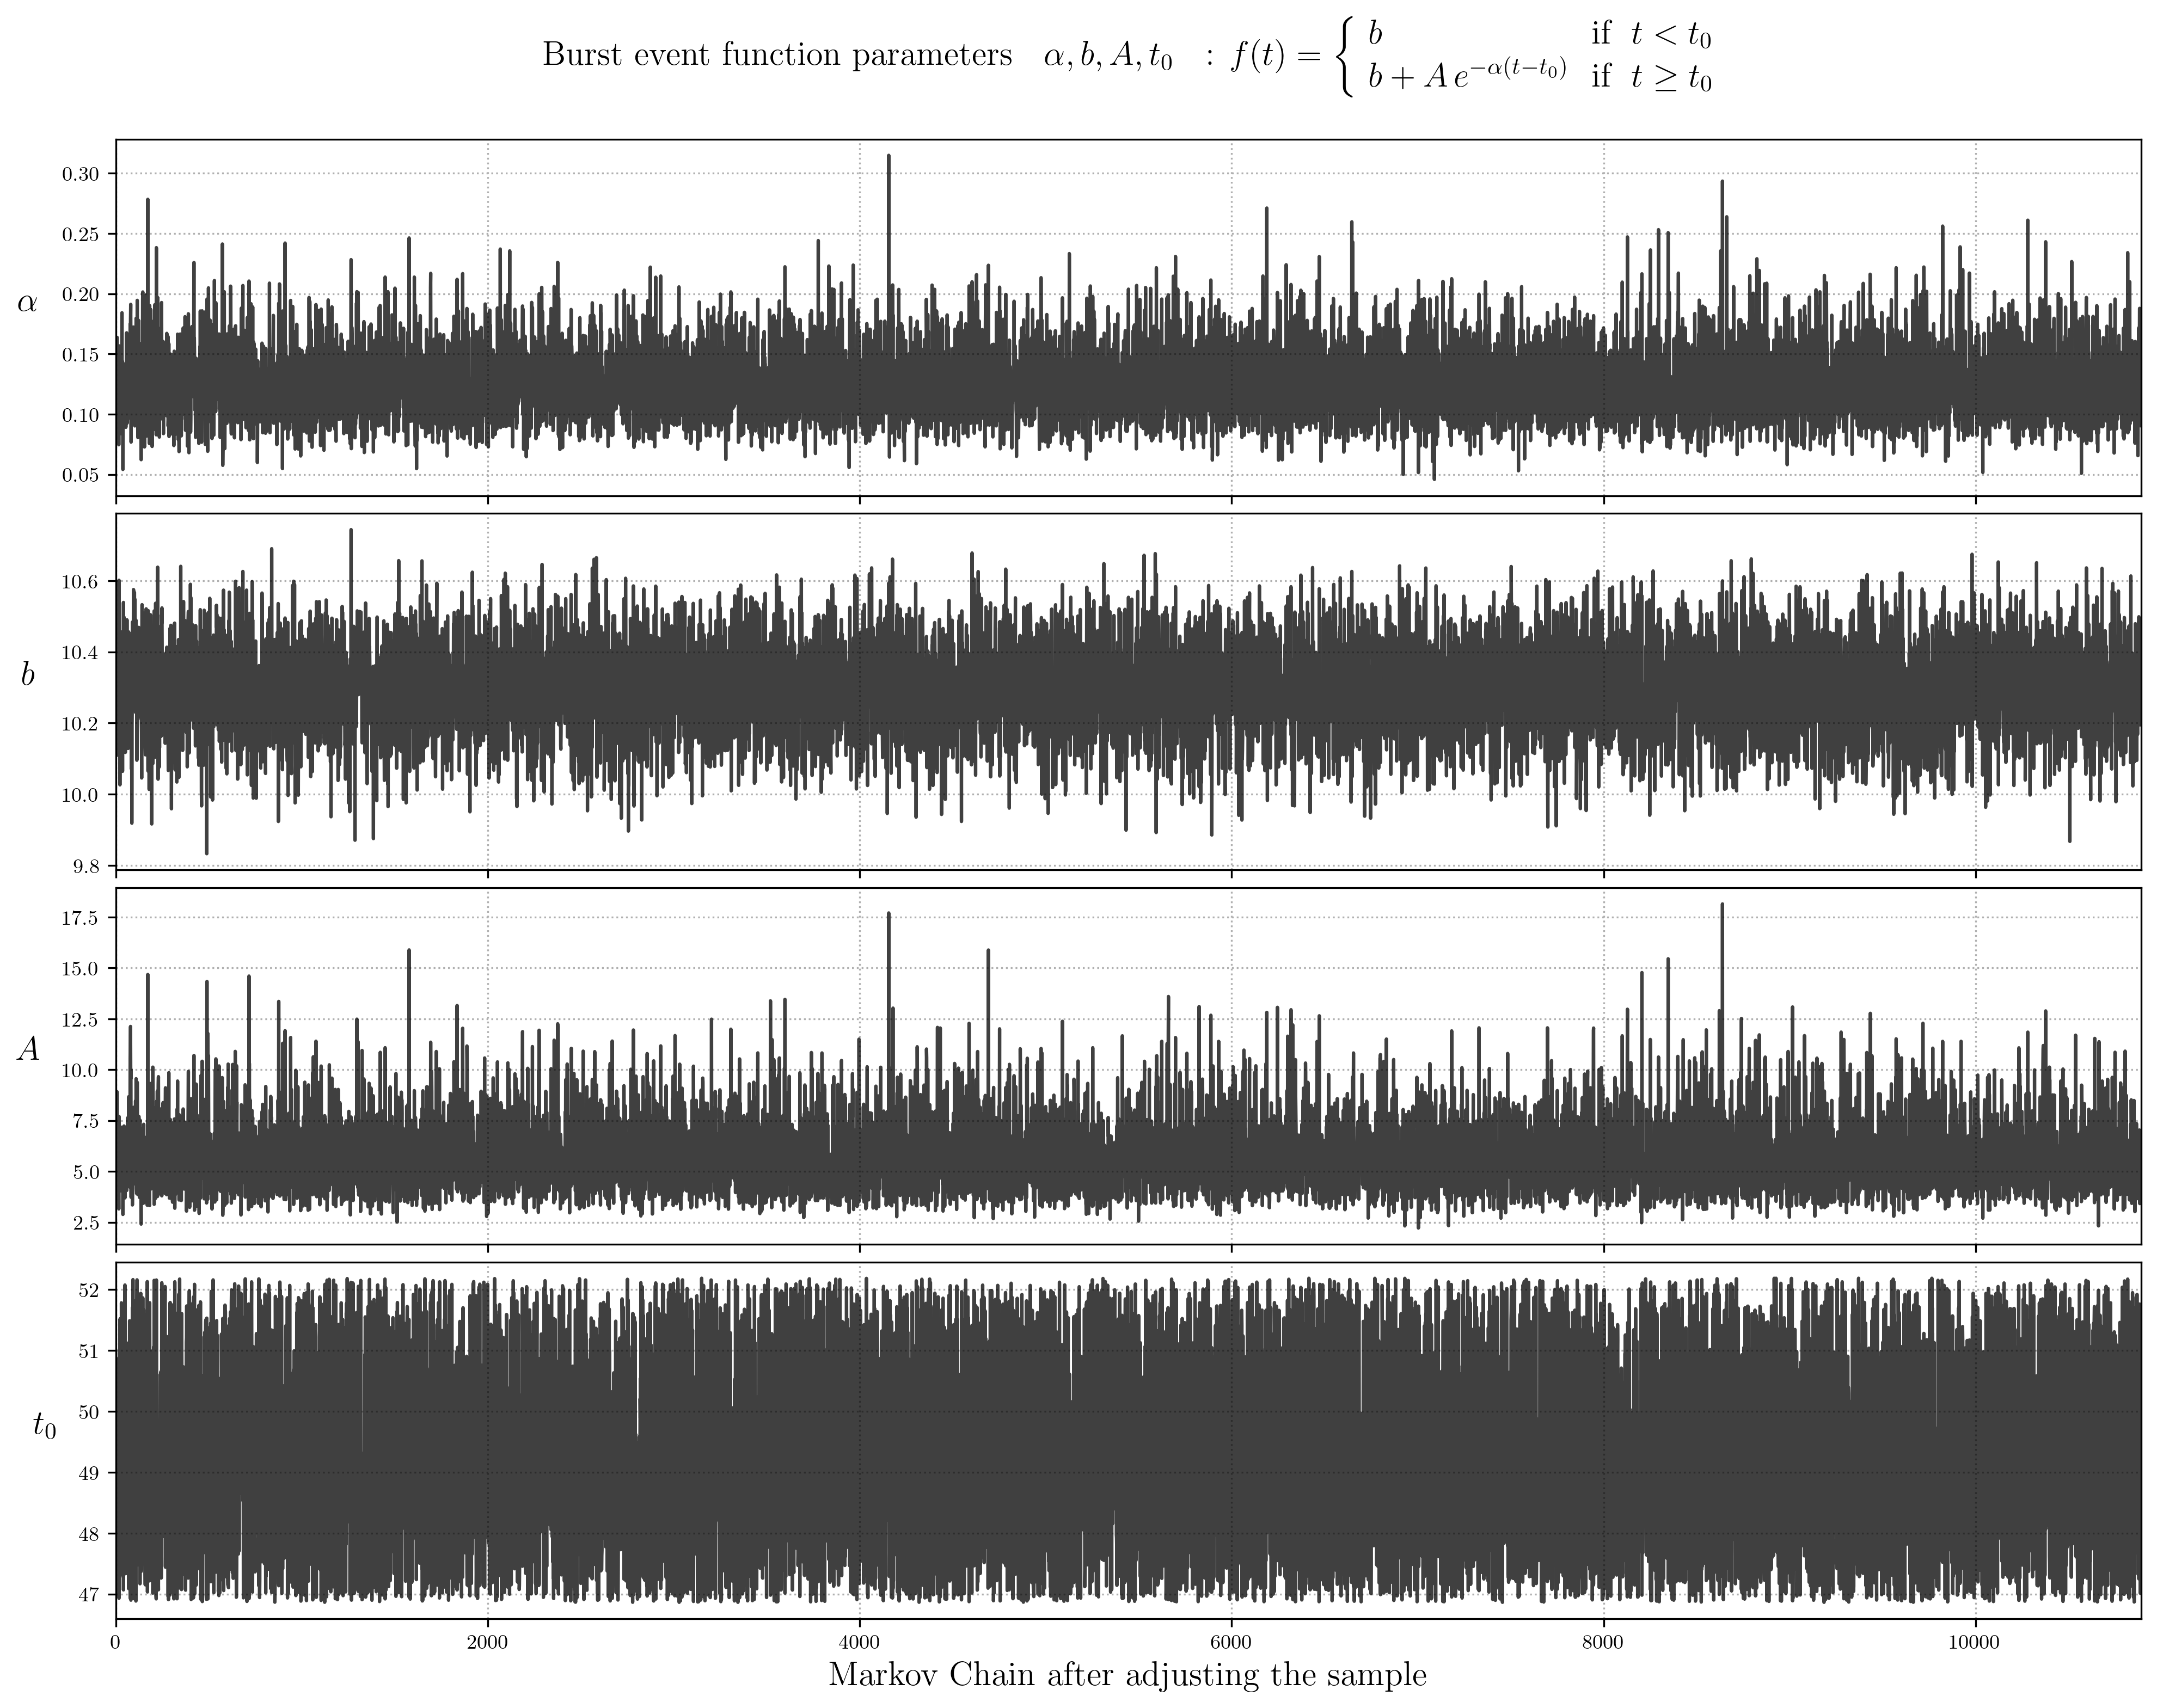

In [35]:
#-------------------------------------------------------------------------
# Plot the results for the MCMC after burn-in, thinning, flattening:
#-------------------------------------------------------------------------

fig , ax = plt.subplots(4,1, figsize=(16,12), sharex=True)

ax = ax.reshape(4)
fig.subplots_adjust(hspace=0.05)

MCtitle = r'Burst event function parameters \; $\alpha, b, A, t_0 $ \; : ' + latexfunc + '\n'
ax[0].set_title(MCtitle, fontsize=15)

ax[3].set_xlabel('Markov Chain after adjusting the sample'.format(n_walkers), fontsize=15)
ylabels = [r'$\alpha$', r'$b$', r'$A$', r'$t_0$' ]
for i in range(n_dim):
    ax[i].grid(ls=':')
    ax[i].set_xlim(0,M)
    ax[i].set_ylabel( ylabels[i], fontsize=15, rotation='horizontal', labelpad=15)

#-------------------------------------------------------------------------
# traceplot fo the MCMC parameters (burned, thinned, flattened)

for i in range(n_dim):
    ax[i].plot(MCMC_trace[:,i], color='black', alpha=0.75)

#-------------------------------------------------------------------------

if True:
    fig.savefig('./L12_images/L12_emcee__Trace_Plot.pdf', bbox_inches='tight')

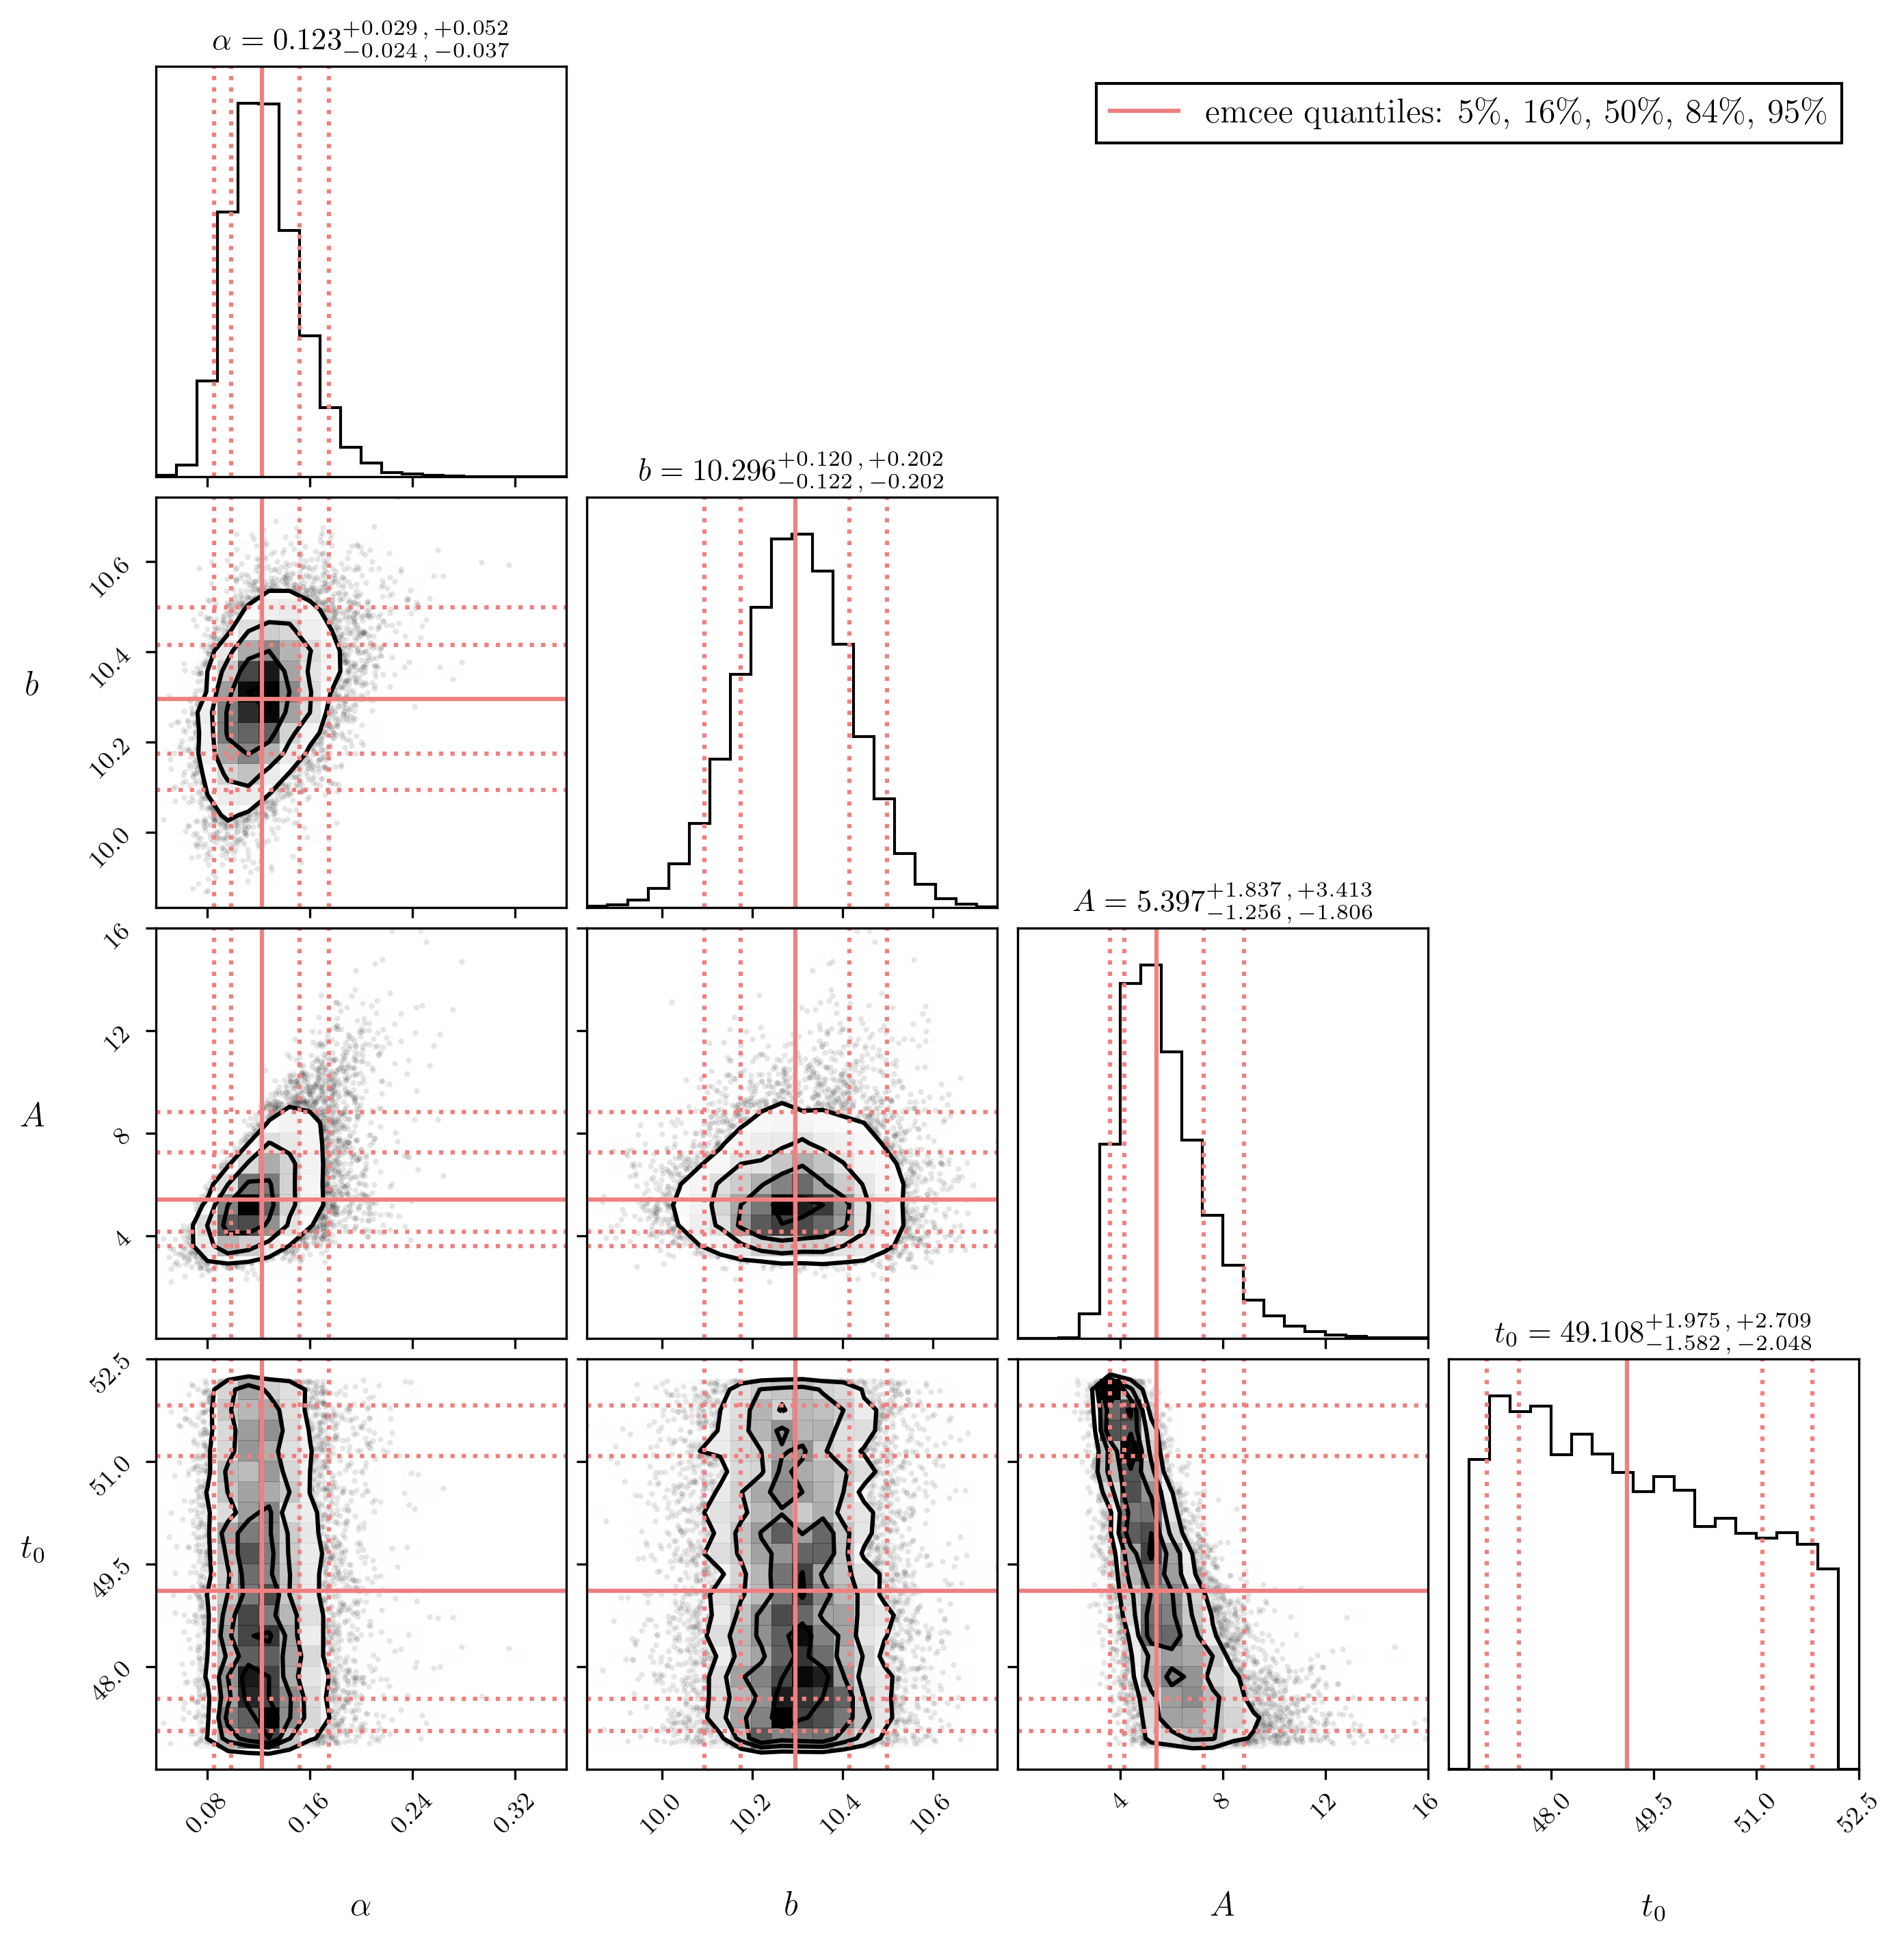

In [62]:
#-------------------------------------------------------------------------
# create the corner plot setup

fontsize = 12
fig = corner.corner(           
    MCMC_trace,
    labels       = ylabels, 
    fontsize     = 12,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize, 'rotation':'horizontal'},
    range        = [(0.04,0.36), 1., (0.,16.), (46.5,52.5)]
)
ax = np.array(fig.axes).reshape((n_dim, n_dim))

#-------------------------------------------------------------------------
# compute ranked statistics for the marginals (1D histograms): quantiles

quantiles0 = np.zeros((5,n_dim))
for i in range(n_dim):
    quantiles0[:,i] = corner.quantile(MCMC_trace[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

#-------------------------------------------------------------------------
# print these quantiles results onto the histograms and as sub-titles 

ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='emcee quantiles: 5\%, 16\%, 50\%, 84\%, 95\%')

corner.overplot_lines(fig, quantiles0[2,:], color="lightcoral")
corner.overplot_lines(fig, quantiles0[0,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles0[1,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles0[3,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles0[4,:], color="lightcoral", ls=':')

par_name = [r'\alpha', 'b', 'A', 't_0']
for i in range(n_dim):
    titles = '$' + par_name[i] + '=' + \
             '{:.3f}'.format(quantiles0[2,i]) + r'^{+' + \
             '{:.3f}'.format(quantiles0[3,i] - quantiles0[2,i]) + r'\, , \,+' + \
             '{:.3f}'.format(quantiles0[4,i] - quantiles0[2,i]) + r'}_{-'      + \
             '{:.3f}'.format(quantiles0[2,i] - quantiles0[1,i]) + r'\, , \,-'  + \
             '{:.3f}'.format(quantiles0[2,i] - quantiles0[0,i]) + r'}$'
    ax[i,i].set_title( titles )

#-------------------------------------------------------------------------
# compute and show also the maximum a posteriori (MAP)

M = len(MCMC_trace[:,0])

MCMC_logpost = np.zeros(M)
for i in range(M):
    MCMC_logpost[i] = logposterior( MCMC_trace[i,:], T, F, eF )
    
x_best = MCMC_trace[ np.argmax(MCMC_logpost) ,:] 

# corner.overplot_lines(fig, x_best, color="lightskyblue")
# ax[0,n_dim-1].plot([], [], marker='', color='lightskyblue', label='Maximum a posteriori')

#-------------------------------------------------------------------------
# utility: make legend, save figure:

ax[0,n_dim-1].legend(title_fontsize=fontsize, fontsize=fontsize, frameon=True, framealpha=1, fancybox=False, edgecolor='black', )

if True:
    fig.savefig('./L12_images/L12_emcee__Corner_Plot.pdf', bbox_inches='tight')


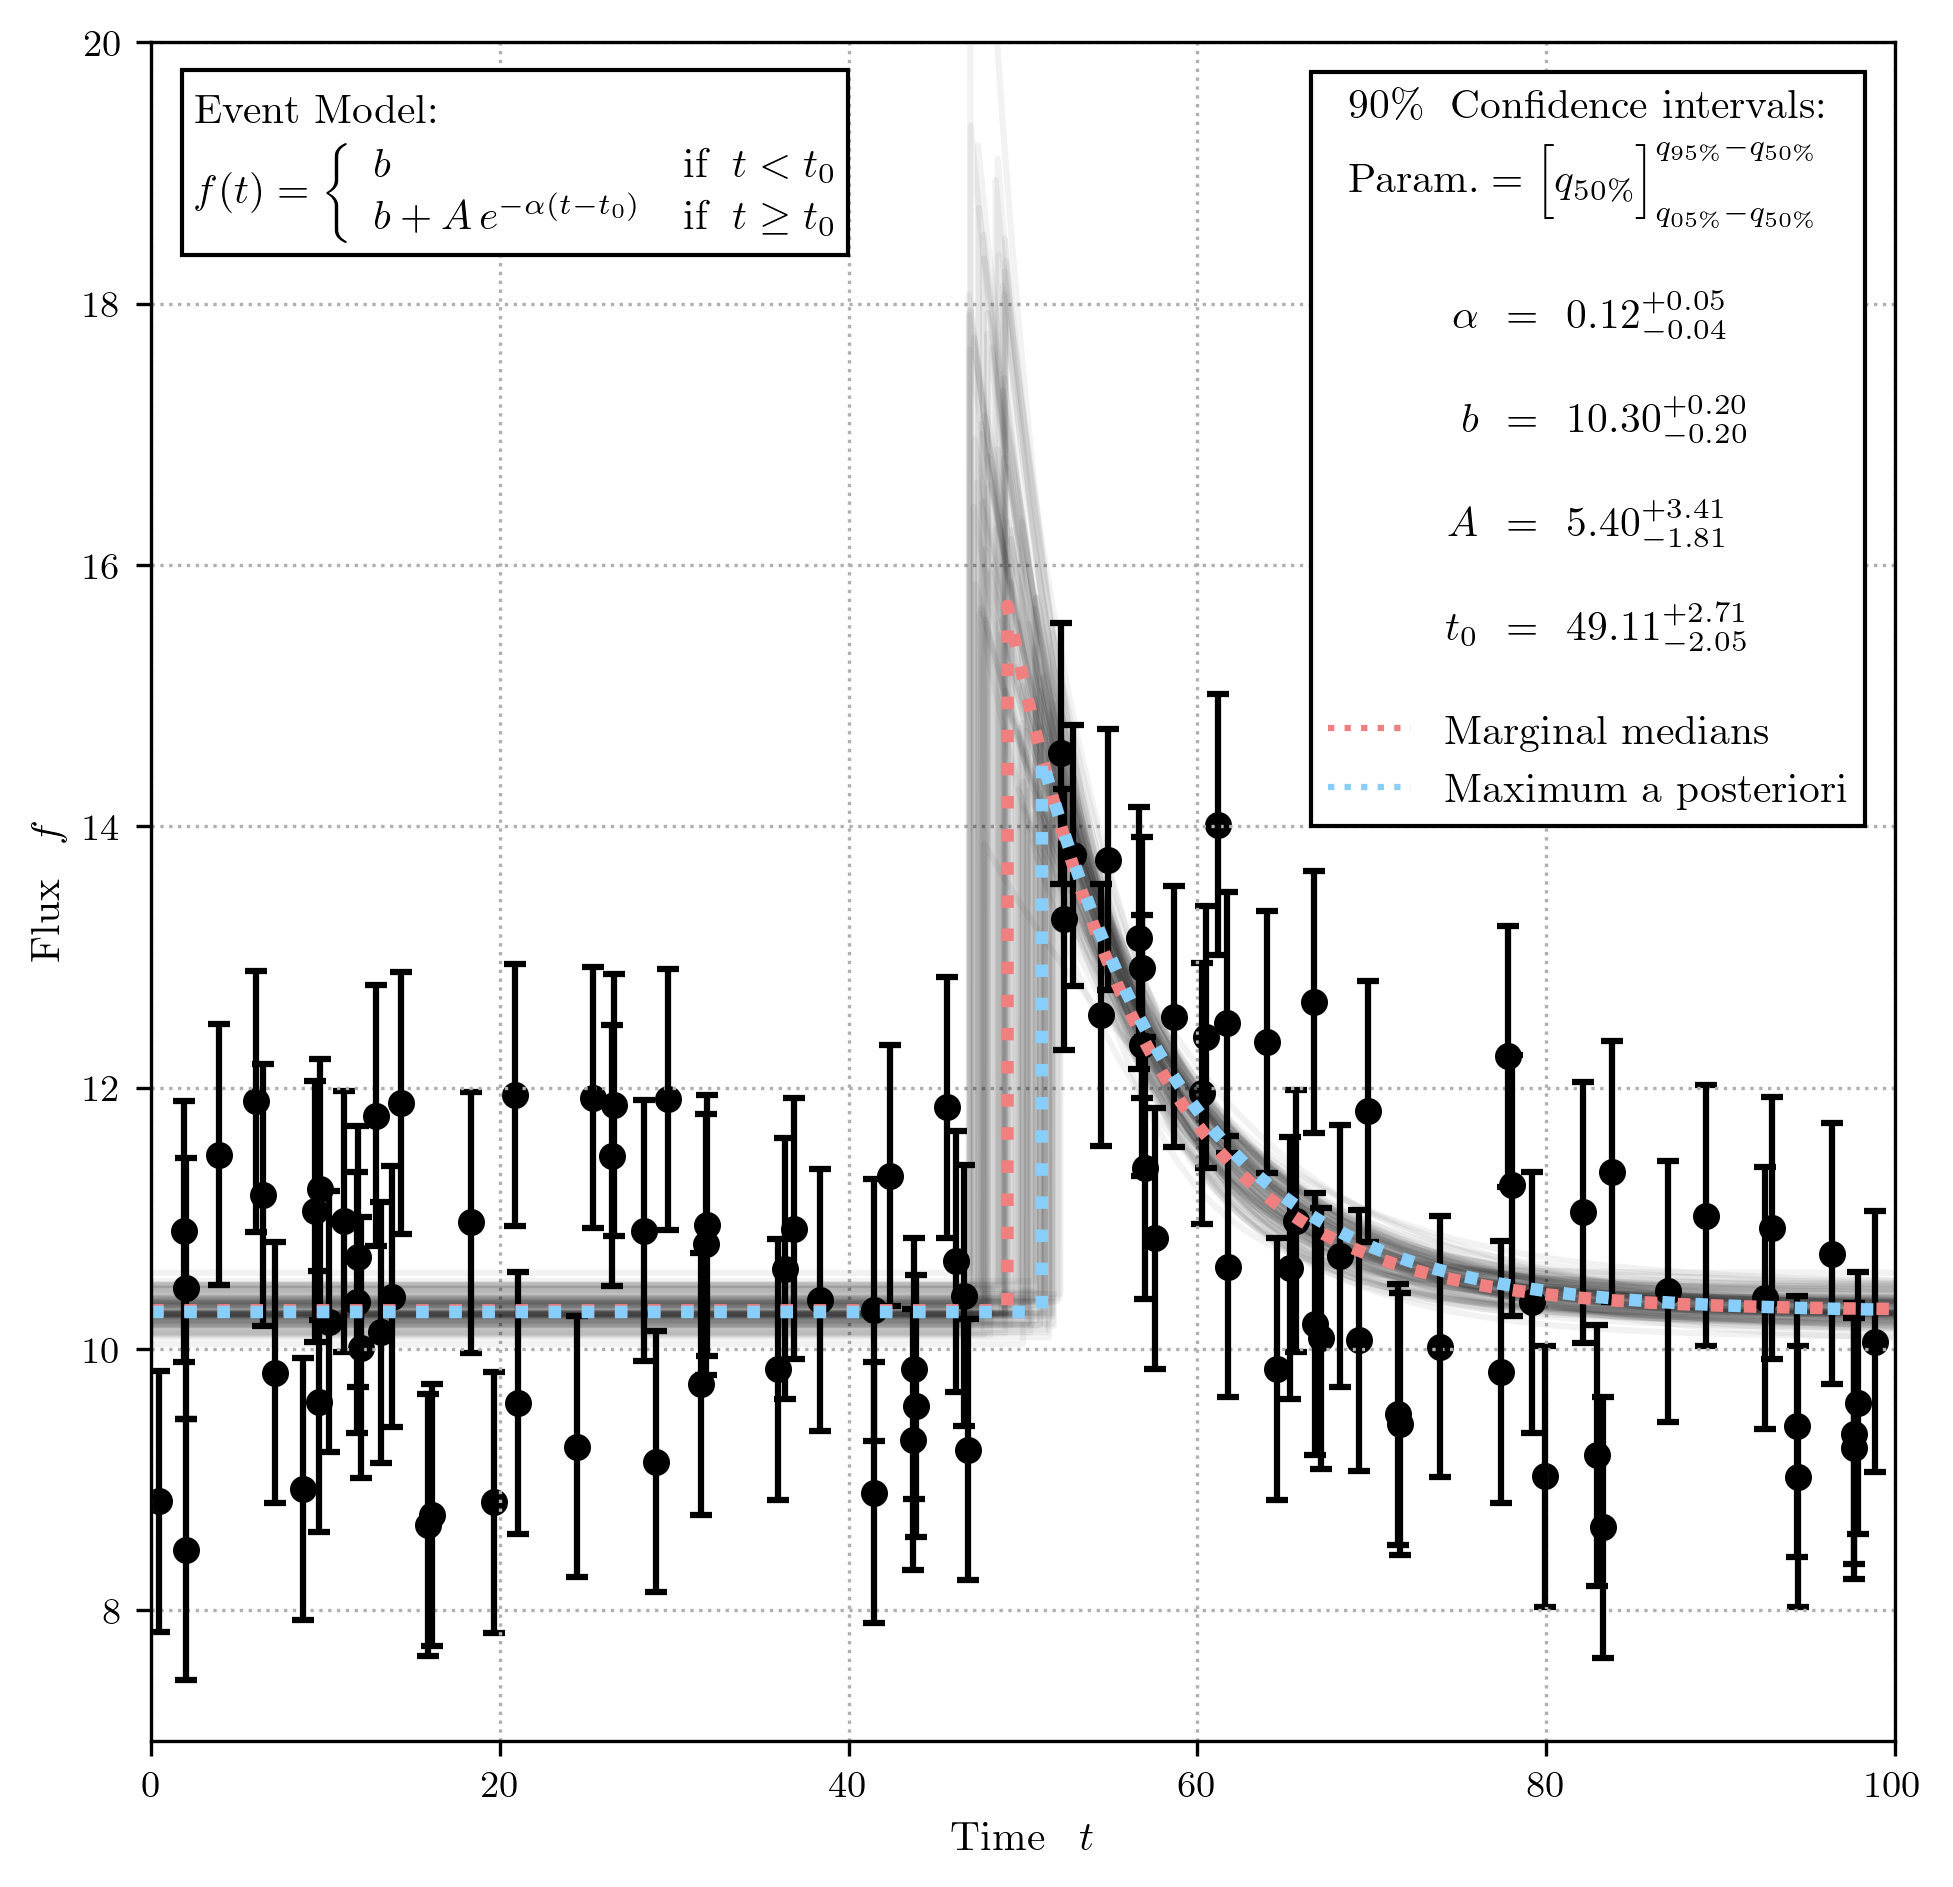

In [37]:
#-------------------------------------------------------------------------
# Plot the results of the parameter estimation over the observed data
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# initialize matplotlib figure and axes

fig , ax = plt.subplots(figsize=(7.5,7.5))
fontsize = 10
ax.set_xlim(0,100)
ax.set_ylim(7,20)
ax.grid(ls=':')
# ax.set_title(r'Event Model: \quad' + latexfunc + '\n', fontsize=15)
ax.set_xlabel(r'Time \, $t$', fontsize=fontsize)
ax.set_ylabel(r'Flux \, $f$', fontsize=fontsize) #, rotation='horizontal', labelpad=30)

#-------------------------------------------------------------------------
# select 100 random [a,b,A,t0] from the MCMC sample:

n_rand = 100
MCMC_100 = MCMC_trace[ np.random.choice( len(MCMC_trace[:,0]) , size=n_rand, replace=False) , :]

#-------------------------------------------------------------------------
# plot the function "event" f(t) for these 100 tuples of parameters:

t_lin = np.linspace(0, 100, 10000)
for i in range(n_rand):
    y_lin = flux_model(MCMC_100[i,:], t_lin)
    ax.plot(t_lin, y_lin, color='black', alpha=0.05)
    
#-------------------------------------------------------------------------
# plot the original data:

for i in range(len(T)):                                                       #for t, f, ef in zip(T, F, eF):
    ax.vlines(T[i], ymin=F[i]-eF[i], ymax=F[i]+eF[i], color='black' )          #ax.vlines( t, ymin=t-ef, ymax=t+ef)
ax.scatter(T, F + eF, color='black', s=30, marker='_')
ax.scatter(T, F - eF, color='black', s=30, marker='_')
ax.scatter(T, F, color='black', s=30, marker='o') # , label='')

#-------------------------------------------------------------------------
# plot the median and 90% credible region of the marginalized distribution: (done something similar above)

legend_title  = r'90\%' + '\; Confidence intervals:' + '\n' + 'Param.'
legend_title += r'$ \; = \Big[ q_{50\%} \Big]^{ q_{95\%} - q_{50\%}}_{ q_{05\%} - q_{50\%}}  $' + '\n'
label_results = '$' + r'\begin{array}{rcl}'

for i in range(n_dim):
    label_results += par_name[i] + r'\!&\! = \!&\!' + \
             '{:2.2f}'.format(quantiles[2,i]) + r'^{+' + \
             '{:1.2f}'.format(quantiles[4,i] - quantiles[2,i]) + r'}_{-'      + \
             '{:1.2f}'.format(quantiles[2,i] - quantiles[0,i]) + r'}' + r'\\ \\'
label_results += r'\end{array} $' + '\n'

ax.scatter( [], [], marker='', label=label_results)

#-------------------------------------------------------------------------
# plot also the best fit curve computed with the medians:

y_lin = flux_model(quantiles[2,:], t_lin)
ax.plot(t_lin, y_lin, color='lightcoral', alpha=1., ls=':', lw=3)
ax.plot([], [], ls=':', color='lightcoral', label='Marginal medians')

#-------------------------------------------------------------------------
# plot also the best fit curve computed with the maximum a posteriori:

M = len(MCMC_trace[:,0])
MCMC_logpost = np.zeros(M)
for i in range(M):
    MCMC_logpost[i] = logposterior( MCMC_trace[i,:], T, F, eF )

x_best = MCMC_trace[ np.argmax(MCMC_logpost) ,:] 
    
y_lin = flux_model(x_best, t_lin)
ax.plot(t_lin, y_lin, color='lightskyblue', alpha=1., ls=':', lw=3)
ax.plot([], [], ls=':', color='lightskyblue', label='Maximum a posteriori')

#-------------------------------------------------------------------------
# Utilities: plot the 'title' with the functional form of the transient event model, save figure

ax.legend(title=legend_title, 
          title_fontsize=fontsize, 
          fontsize=fontsize, 
          frameon=True, 
          framealpha=1, 
          fancybox=False, 
          edgecolor='black', 
          loc='upper right',
          bbox_to_anchor=(0.995,0.995)
         )

props = dict(boxstyle='square', facecolor='white', alpha=1.)

string = ax.text(0.025, 0.995, 
                 '\n' + r'Event Model:' + '\n' + latexfunc, 
                 transform=ax.transAxes, 
                 fontsize=fontsize,
                 verticalalignment='top', 
                 horizontalalignment='left', 
                 bbox=props
                )

if True:
    fig.savefig('./L12_images/L12_emcee__Observations_and_Estimated_Parameters.pdf', bbox_inches='tight')


# Now do this with dynesty, with the same burst model

$$
\textup{transient event model:}
\qquad
f\big(\,t \,|\, t_0, A, \alpha, b \,\big) = \left\{
\begin{array}{ll}
    b & \textup{if } t \leq t_0 
    \\
    b + A \exp\Big( \!\!-\!\alpha\big(t-t_0 \big) \Big)
    & \textup{if } t > t_0
\end{array}
\right.
$$

In [38]:
#-------------------------------------------------------------------------
# define all the functions
#-------------------------------------------------------------------------

def flux_model(x, t):  
    return np.where( t > x[3] , x[1] + x[2] * np.exp( -x[0]*(t-x[3]) ) , x[1] )

def log_prior(x):
    if -5 < np.log(x[0]) < 5 and 0 < x[1] < 50 and 0 < x[2] < 50 and 0 < x[3] < 100 :
        return np.log(1/x[0]) + np.log(1/50) + np.log(1/50) + np.log(1/100)
    return -np.inf

def loglikelihood(x, t, f, ef):
    return  - 1/2 * np.sum( ( f - flux_model(x, t) )**2 / ef**2 + np.log(2*np.pi*ef**2) )

def prior_transform(x):
    xt = np.copy(x)
    # stats.distribution.ppf means stats.distribution.cdf_inverse: 
    # it's like using transverse 
    xt[0] = stats.loguniform.ppf(x[0],np.exp(-5),np.exp(5))  # xt[0] = np.exp(5*(2*x[0]-1)) / x[0]   
    xt[1] = stats.uniform(loc=0,scale=50).ppf(x[1])          # xt[1] = 50  * x[1]                    
    xt[2] = stats.uniform(loc=0,scale=50).ppf(x[2])          # xt[2] = 50  * x[2]                    
    xt[3] = stats.uniform(loc=0,scale=100).ppf(x[3])         # xt[3] = 100 * x[3]                    
    return xt

latexfunc = r'$ f(t) = ' \
          + r'\left\{ \begin{array}{ll}' \
          + r'b & \textup{if } \; t < t_0 \\' \
          + r'b + A \, e^{-\alpha(t - t_0)} & \textup{if } \; t \geq t_0' \
          + r'\end{array} \right. $'


#-------------------------------------------------------------------------

In [39]:
#-------------------------------------------------------------------------
# Monte Carlo Markov Chain: dynesty (static)
#-------------------------------------------------------------------------

sampler_dynesty1 = dynesty.NestedSampler(loglikelihood, prior_transform, n_dim, logl_args=(T,F,eF), nlive=1000)
sampler_dynesty1.run_nested()
sresults1 = sampler_dynesty1.results

print('dynesty: done')

#-------------------------------------------------------------------------

C:\Users\andre\AppData\Local\Temp\ipykernel_9864\2675783483.py:6: RuntimeWarning: overflow encountered in exp
  return np.where( t > x[3] , x[1] + x[2] * np.exp( -x[0]*(t-x[3]) ) , x[1] )
C:\Users\andre\AppData\Local\Temp\ipykernel_9864\2675783483.py:6: RuntimeWarning: overflow encountered in multiply
  return np.where( t > x[3] , x[1] + x[2] * np.exp( -x[0]*(t-x[3]) ) , x[1] )
3609it [01:47,  7.18it/s, bound: 0 | nc: 83 | ncall: 36125 | eff(%):  9.990 | loglstar:   -inf < -272.488 <    inf | logz: -280.856 +/-  0.123 | dlogz: 118.870 >  1.009]    C:\Users\andre\AppData\Local\Temp\ipykernel_9864\2675783483.py:6: RuntimeWarning: overflow encountered in exp
  return np.where( t > x[3] , x[1] + x[2] * np.exp( -x[0]*(t-x[3]) ) , x[1] )
3671it [01:48, 76.02it/s, bound: 1 | nc: 1 | ncall: 36231 | eff(%): 10.132 | loglstar:   -inf < -263.065 <    inf | logz: -272.478 +/-  0.126 | dlogz: 110.585 >  1.009] C:\Users\andre\AppData\Local\Temp\ipykernel_9864\2675783483.py:6: RuntimeWarning: overflo

dynesty: done


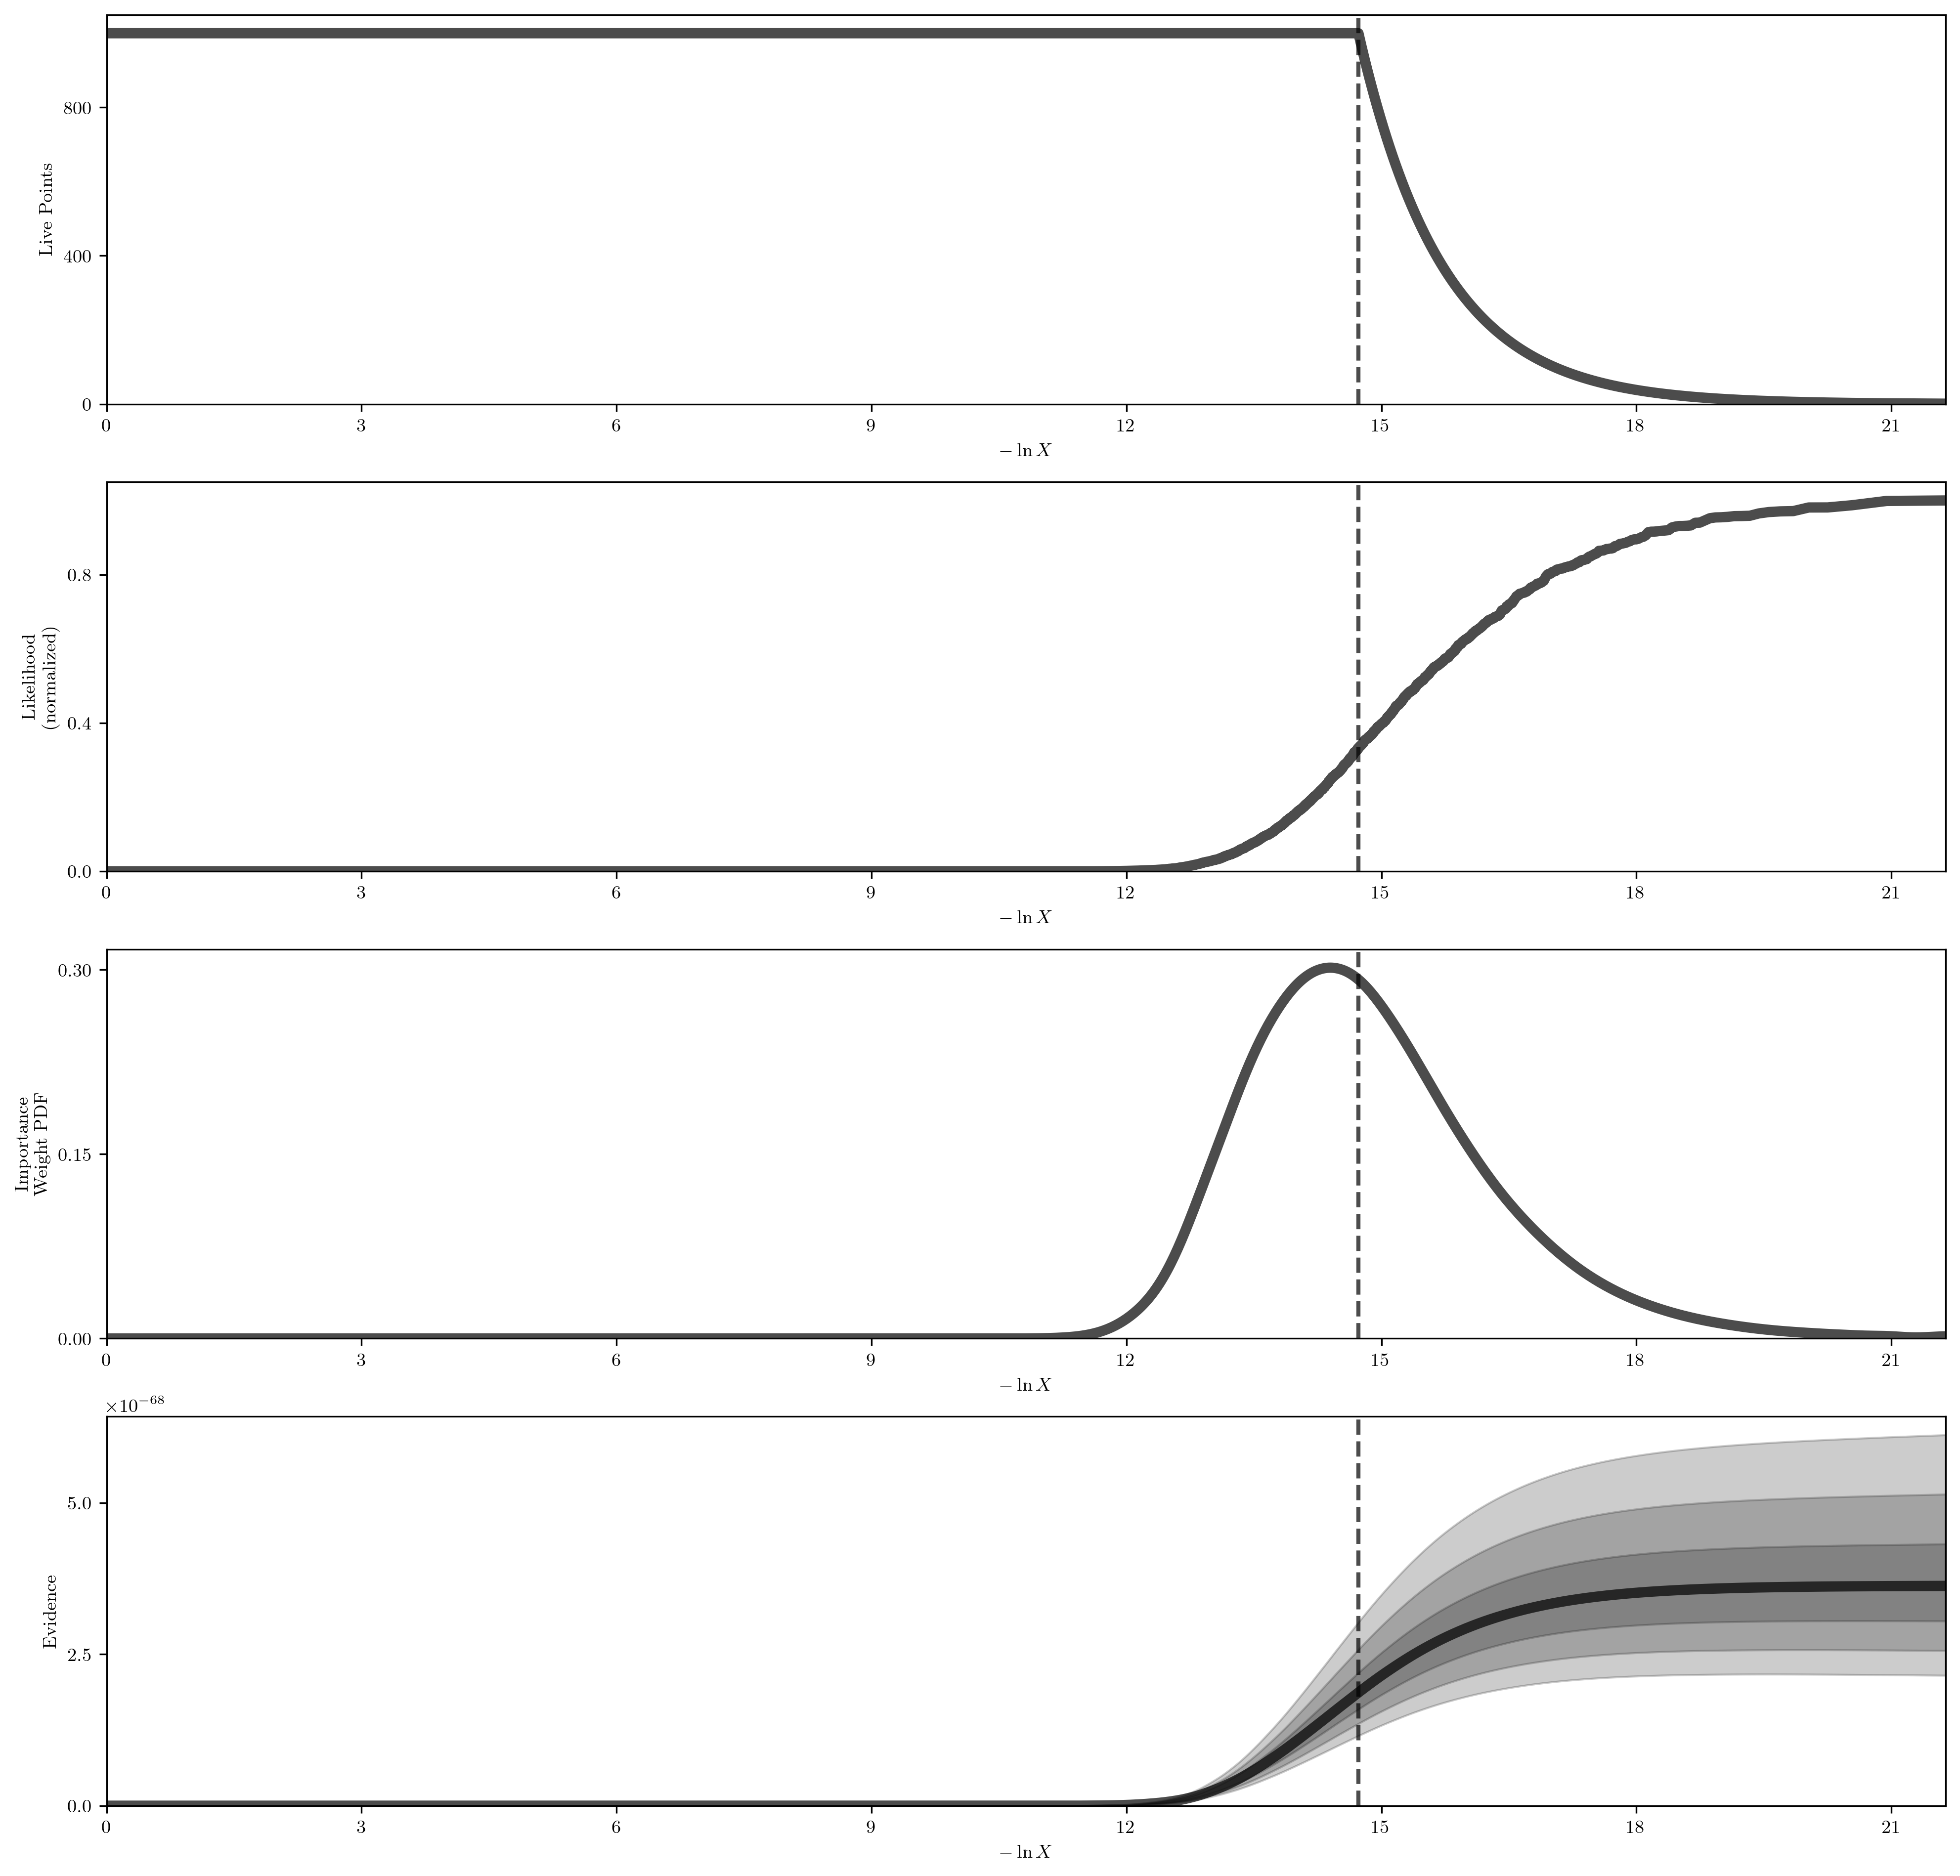

In [40]:
rfig, raxes = dyplot.runplot(sresults1, color='black')

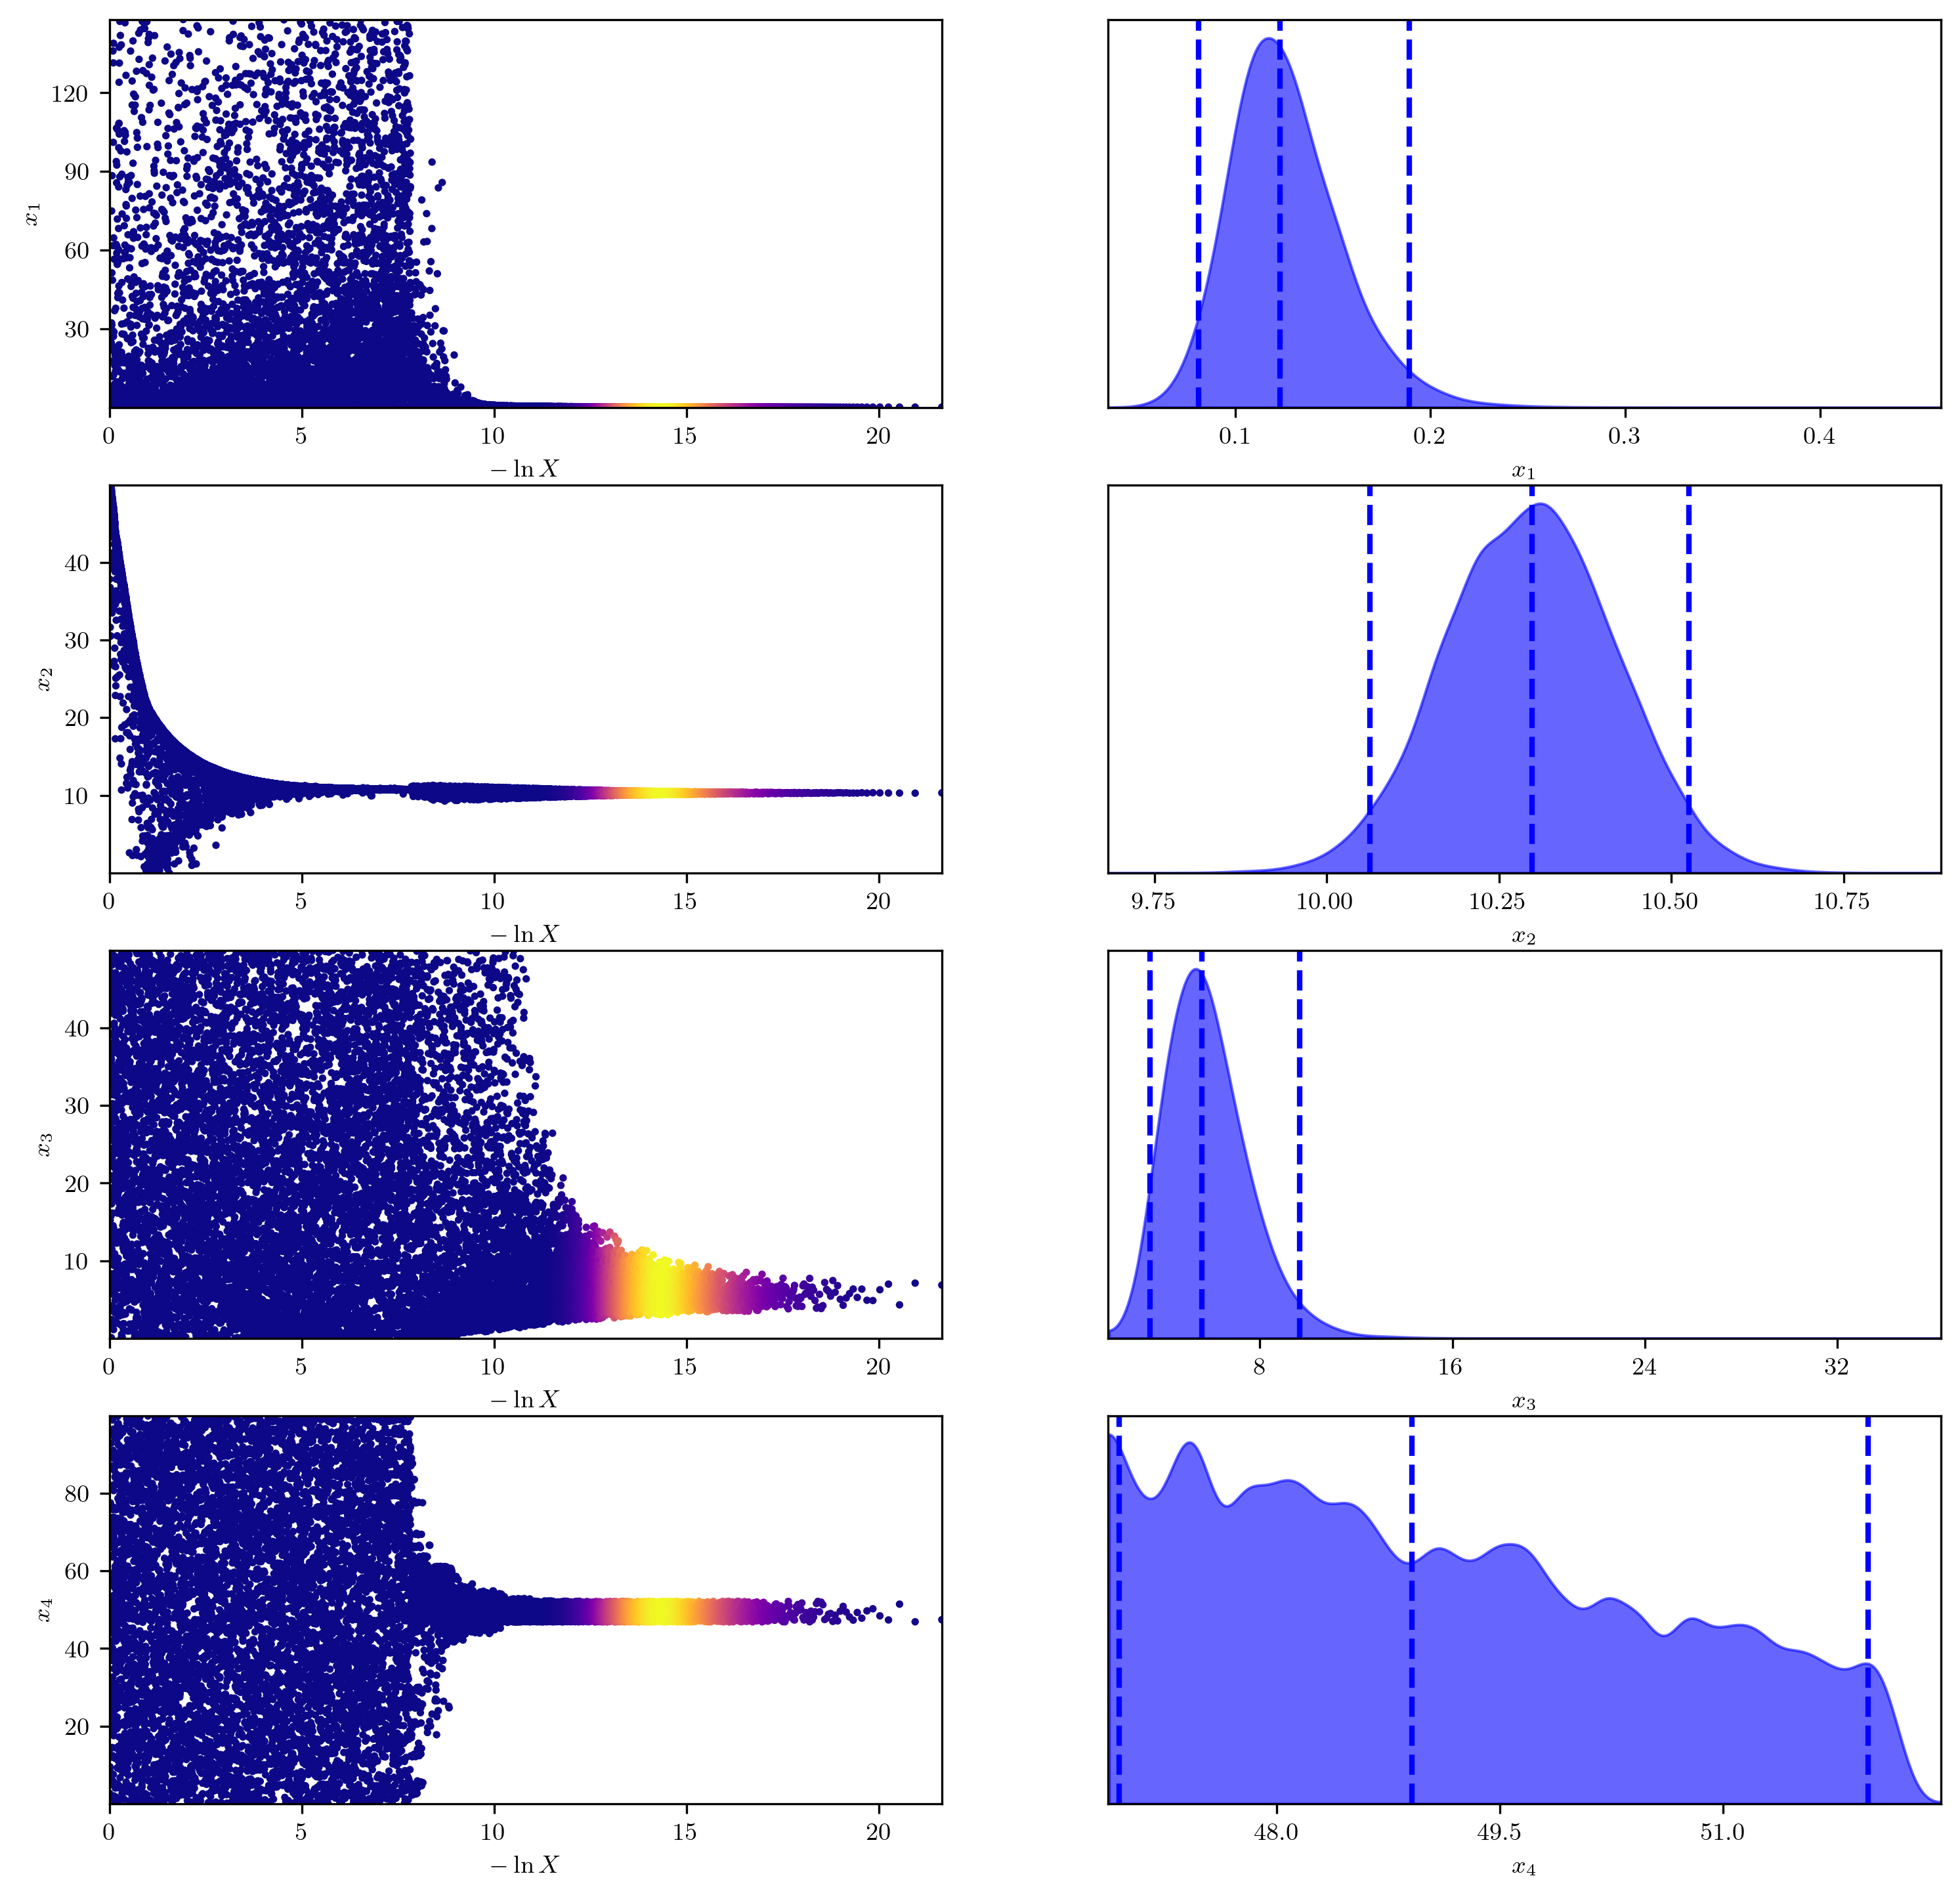

In [41]:
tfig, taxes = dyplot.traceplot(sresults1)

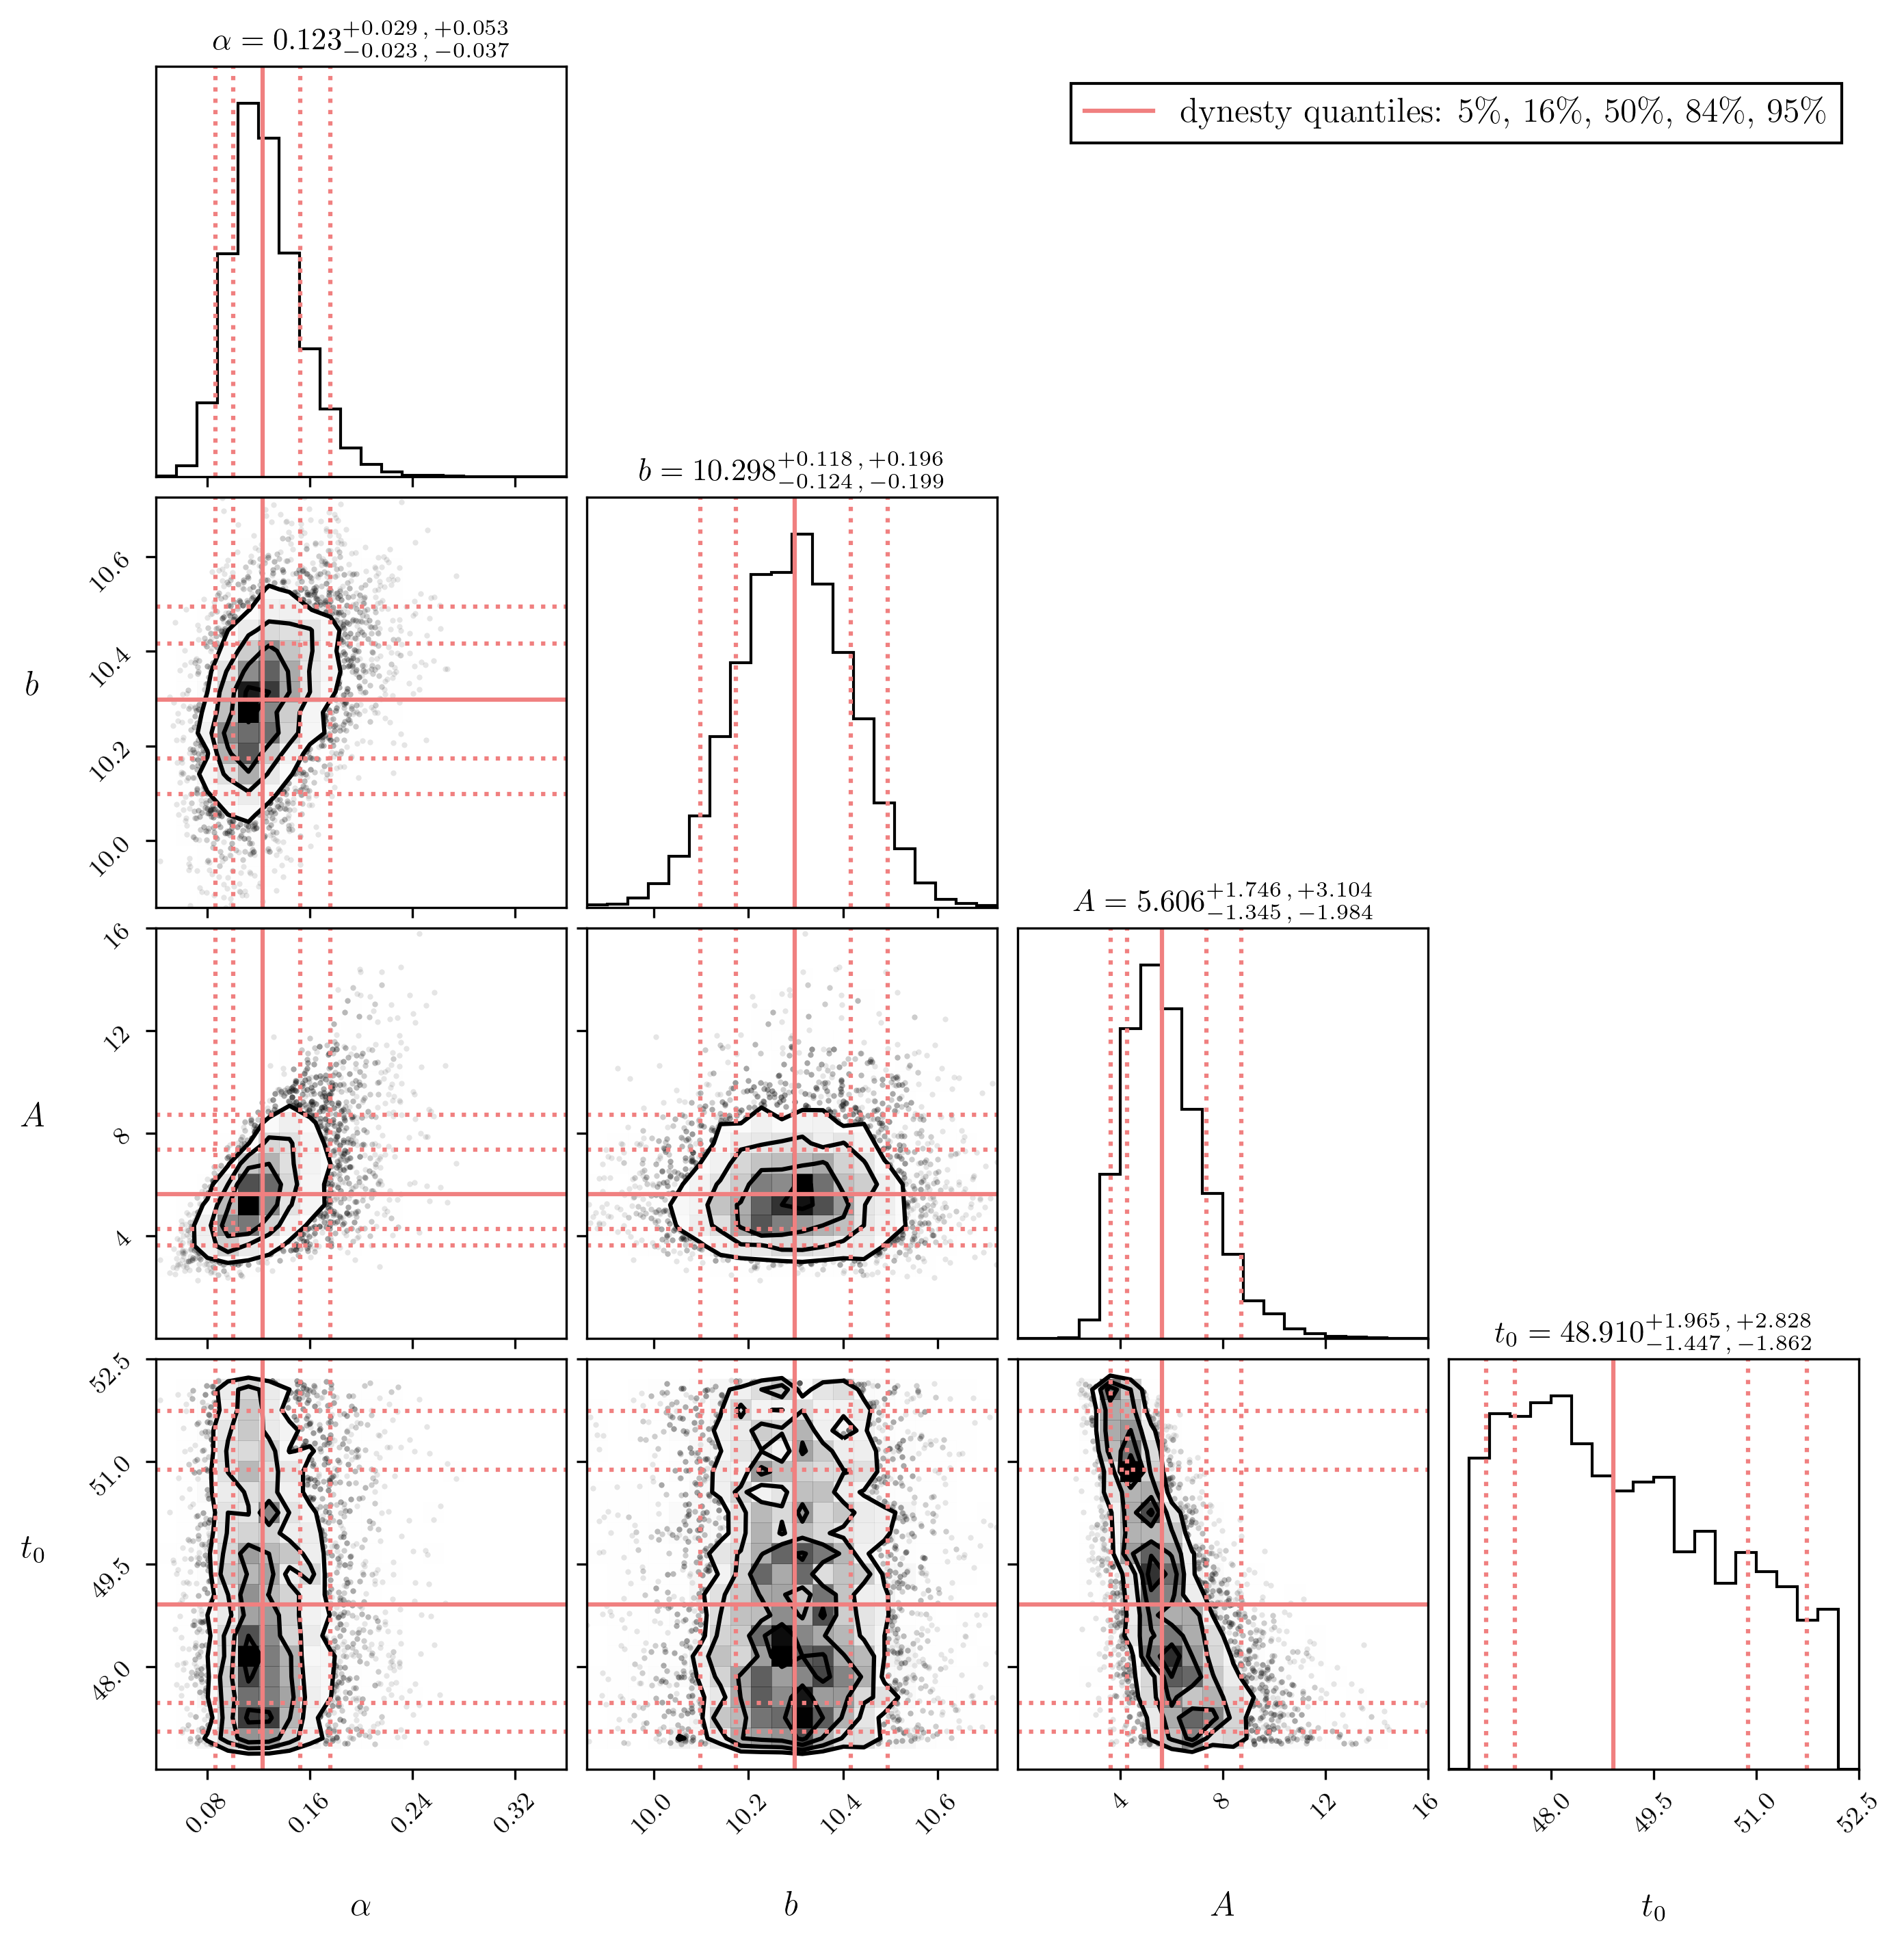

In [63]:
#-------------------------------------------------------------------------
# 

samples = sresults1.samples  
normalized_weights = np.exp(sresults1.logwt - sresults1.logz[-1])
samples_equal = dyfunc.resample_equal(samples, normalized_weights)


#-------------------------------------------------------------------------
# create the corner plot setup with the corner python package
# dynesty built-in corner plots: 
# cfig, caxes = dyplot.cornerplot(sresults1)

params_latex = [r'$\alpha$','$b$', '$A$', '$t_0$']
fontsize = 12
fig = corner.corner(
    samples_equal,
    labels=params_latex,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize, 'rotation':'horizontal'},
    range        = [(0.04,0.36), 1., (0.,16.), (46.5,52.5)]
)
ax = np.array(fig.axes).reshape((n_dim, n_dim))

#-------------------------------------------------------------------------
# compute ranked statistics for the marginals (1D histograms): quantiles

quantiles1 = np.zeros((5,n_dim))
for i in range(n_dim):
    quantiles1[:,i] = corner.quantile(samples_equal[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

#-------------------------------------------------------------------------
# print these quantiles results onto the histograms and as sub-titles 

ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='dynesty quantiles: 5\%, 16\%, 50\%, 84\%, 95\%')

corner.overplot_lines(fig, quantiles1[2,:], color="lightcoral")
corner.overplot_lines(fig, quantiles1[0,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[1,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[3,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[4,:], color="lightcoral", ls=':')

par_name = [r'\alpha', 'b', 'A', 't_0']
for i in range(n_dim):
    titles = '$' + par_name[i] + '=' + \
             '{:.3f}'.format(quantiles1[2,i]) + r'^{+' + \
             '{:.3f}'.format(quantiles1[3,i] - quantiles1[2,i]) + r'\, , \,+' + \
             '{:.3f}'.format(quantiles1[4,i] - quantiles1[2,i]) + r'}_{-'      + \
             '{:.3f}'.format(quantiles1[2,i] - quantiles1[1,i]) + r'\, , \,-'  + \
             '{:.3f}'.format(quantiles1[2,i] - quantiles1[0,i]) + r'}$'
    ax[i,i].set_title( titles )

#-------------------------------------------------------------------------
# utility: make legend, save figure:

ax[0,n_dim-1].legend(title_fontsize=fontsize, fontsize=fontsize, frameon=True, framealpha=1, fancybox=False, edgecolor='black', )

if True:
    fig.savefig('./L12_images/L12_dynesty__Corner_Plot.pdf', bbox_inches='tight')


# Now do this with dynesty, with a different burst model

$$
\textup{transient event model:}
\qquad
f\big(\,t \,|\, t_0, A, \sigma_w, b \,\big) = \left\{
\begin{array}{ll}
    b & \textup{if } t \leq t_0 
    \\
    b + A \exp\Big( \!\!-\!\big(t-t_0 \big)^2/2\sigma_w^2 \Big)
    & \textup{if } t > t_0
\end{array}
\right.
$$

In [46]:
#-------------------------------------------------------------------------
# define all the functions
#-------------------------------------------------------------------------

def flux_model2(x, t):  
    return np.where( t > x[3] , x[1] + x[2] * np.exp( -(t-x[3])**2/(2*x[0]**2) ) , x[1] )

def log_prior2(x):
    if -5 < np.log(x[0]) < 5 and 0 < x[1] < 50 and 0 < x[2] < 50 and 0 < x[3] < 100 :
        return np.log(1/x[0]) + np.log(1/50) + np.log(1/50) + np.log(1/100)
    return -np.inf

def loglikelihood2(x, t, f, ef):
    return  - 1/2 * np.sum( ( f - flux_model2(x, t) )**2 / ef**2 + np.log(2*np.pi*ef**2) )

def prior_transform2(x):
    xt = np.copy(x)
    # stats.distribution.ppf means stats.distribution.cdf_inverse: 
    # it's like using transverse 
    xt[0] = stats.loguniform.ppf(x[0],np.exp(-5),np.exp(5))  # xt[0] = np.exp(5*(2*x[0]-1)) / x[0]   
    xt[1] = stats.uniform(loc=0,scale=50).ppf(x[1])          # xt[1] = 50  * x[1]                    
    xt[2] = stats.uniform(loc=0,scale=50).ppf(x[2])          # xt[2] = 50  * x[2]                    
    xt[3] = stats.uniform(loc=0,scale=100).ppf(x[3])         # xt[3] = 100 * x[3]                    
    return xt

latexfunc2 = r'$ f(t) = ' \
          + r'\left\{ \begin{array}{ll}' \
          + r'b & \textup{if } \; t < t_0 \\' \
          + r'b + A \, e^{-(t - t_0)^2/2\sigma_w^2} & \textup{if } \; t \geq t_0' \
          + r'\end{array} \right. $'


#-------------------------------------------------------------------------

In [47]:
#-------------------------------------------------------------------------
# Monte Carlo Markov Chain: dynesty (static)
#-------------------------------------------------------------------------

sampler_dynesty2 = dynesty.NestedSampler(loglikelihood2, prior_transform2, n_dim, logl_args=(T,F,eF), nlive=1000)
sampler_dynesty2.run_nested()
sresults2 = sampler_dynesty2.results

print('dynesty: done')

#-------------------------------------------------------------------------

15284it [03:30, 72.46it/s, +1000 | bound: 41 | nc: 1 | ncall: 96479 | eff(%): 16.878 | loglstar:   -inf < -140.238 <    inf | logz: -155.455 +/-  0.180 | dlogz:  0.001 >  1.009]

dynesty: done


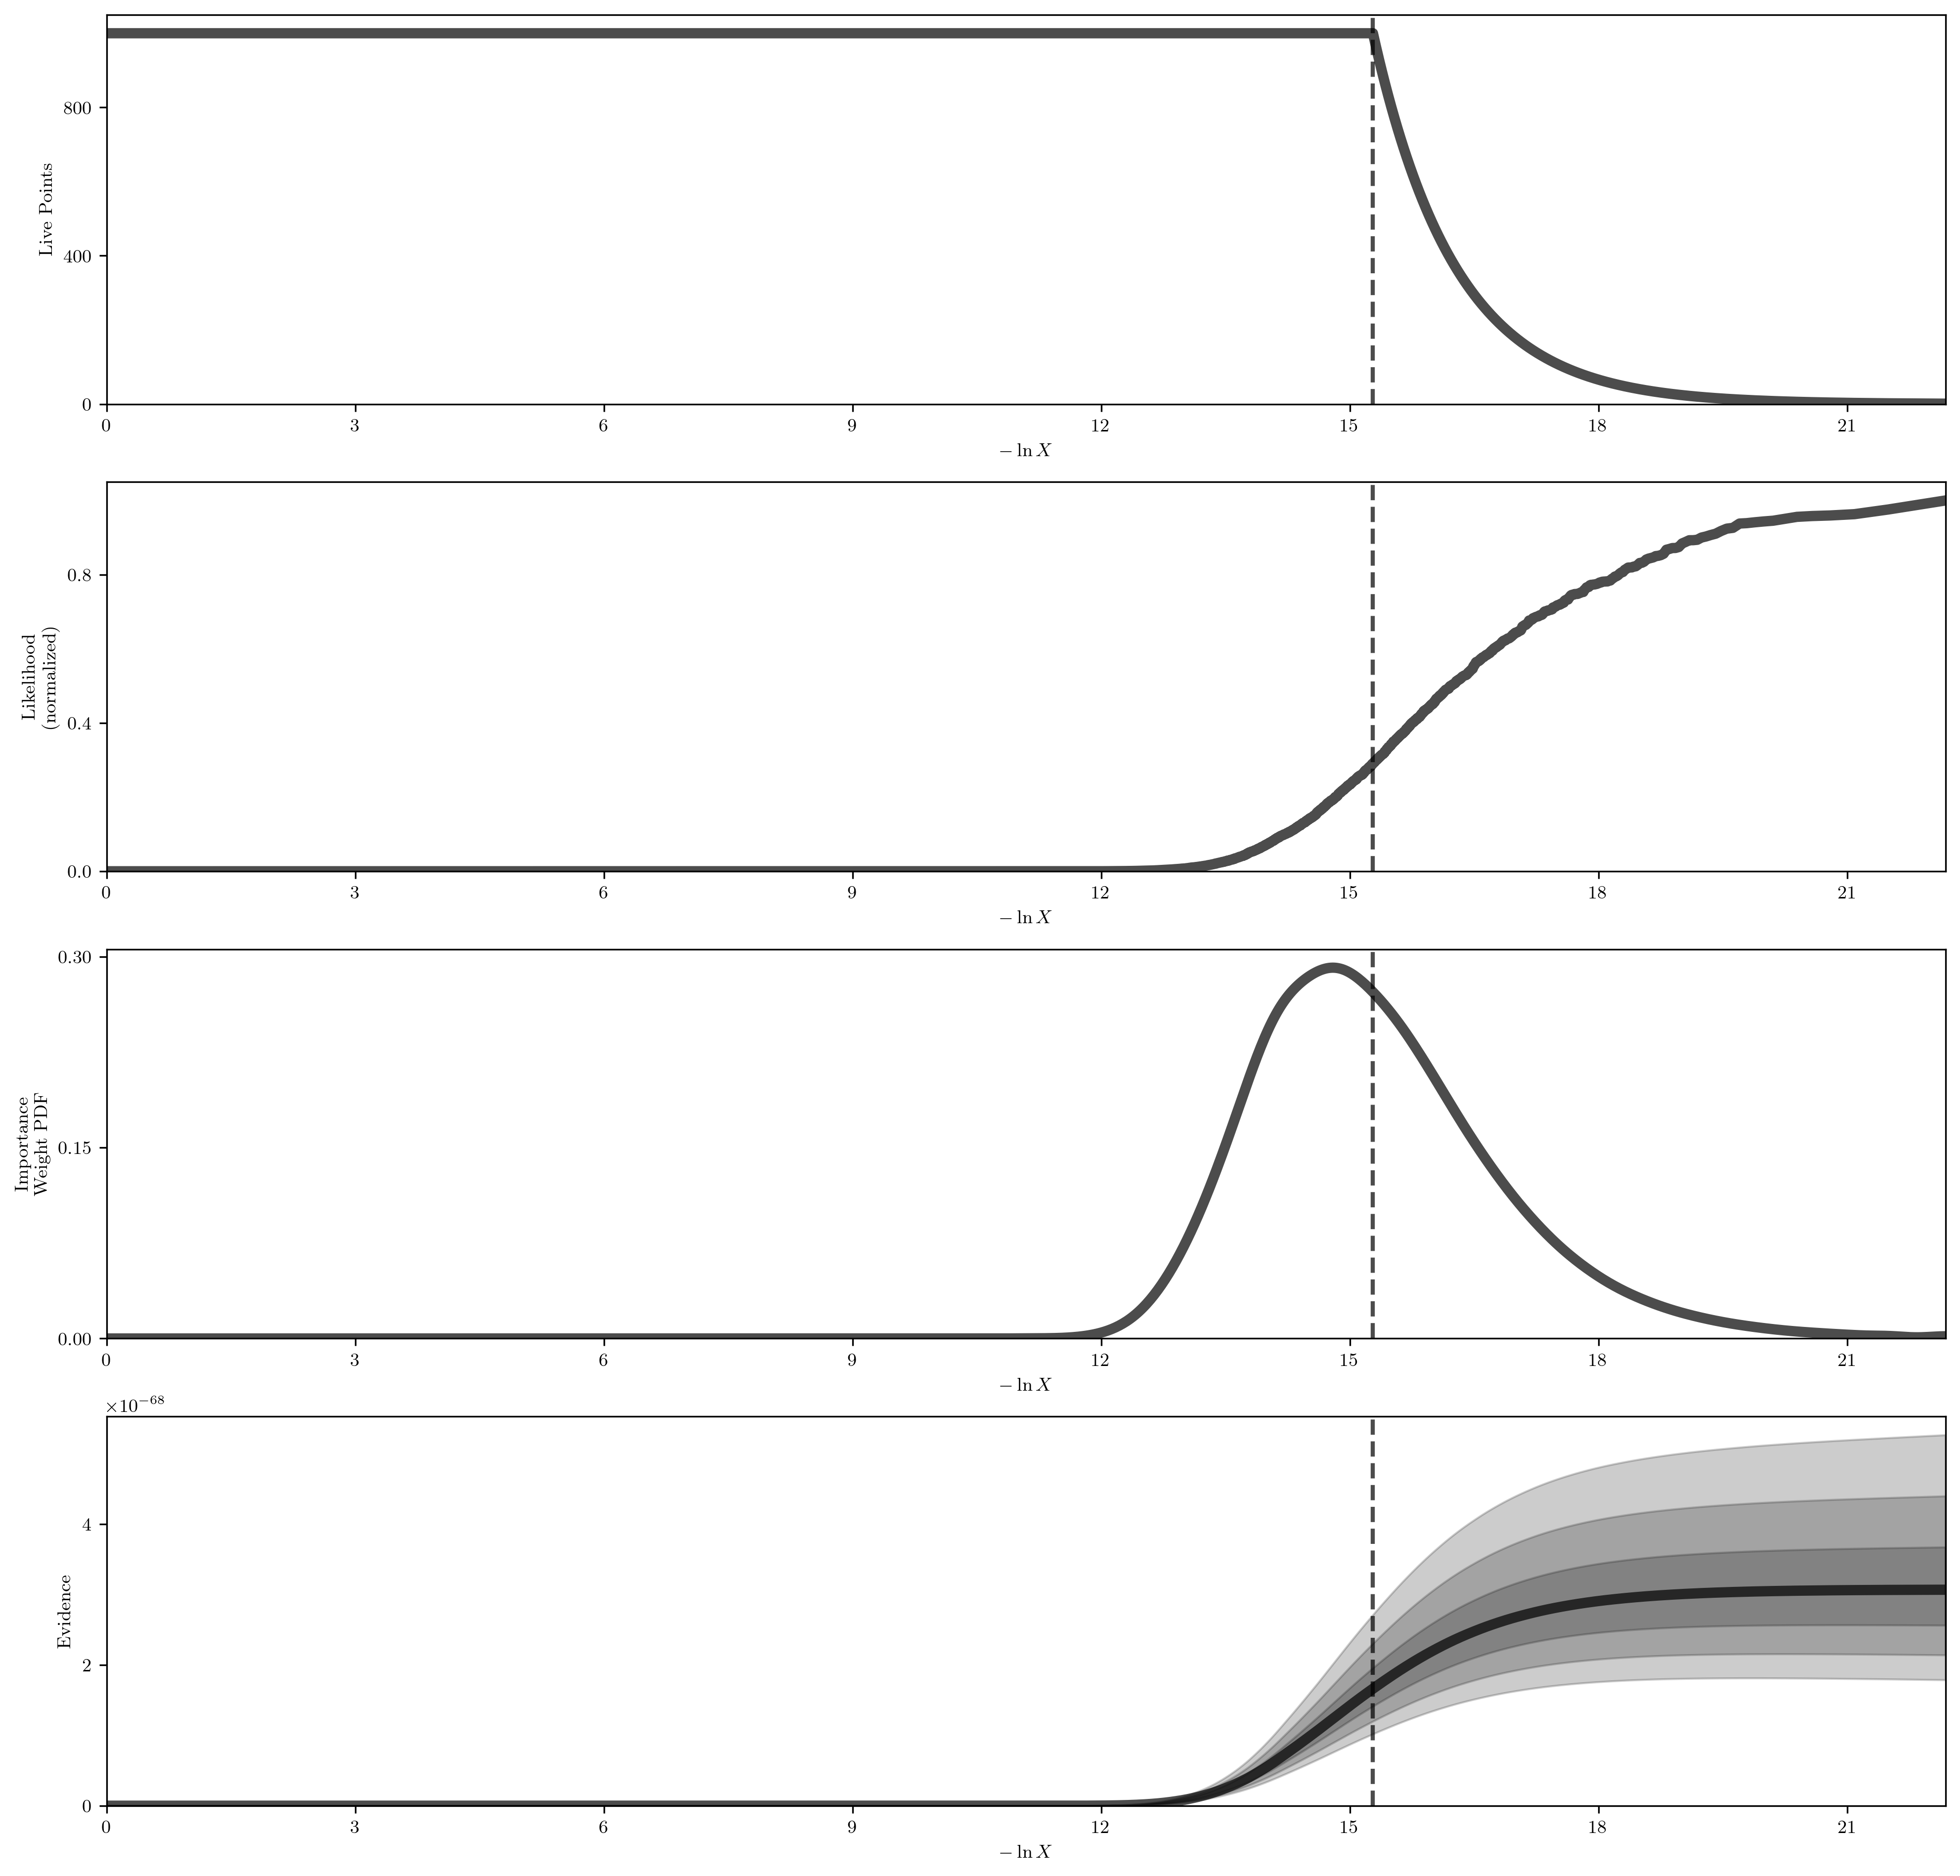

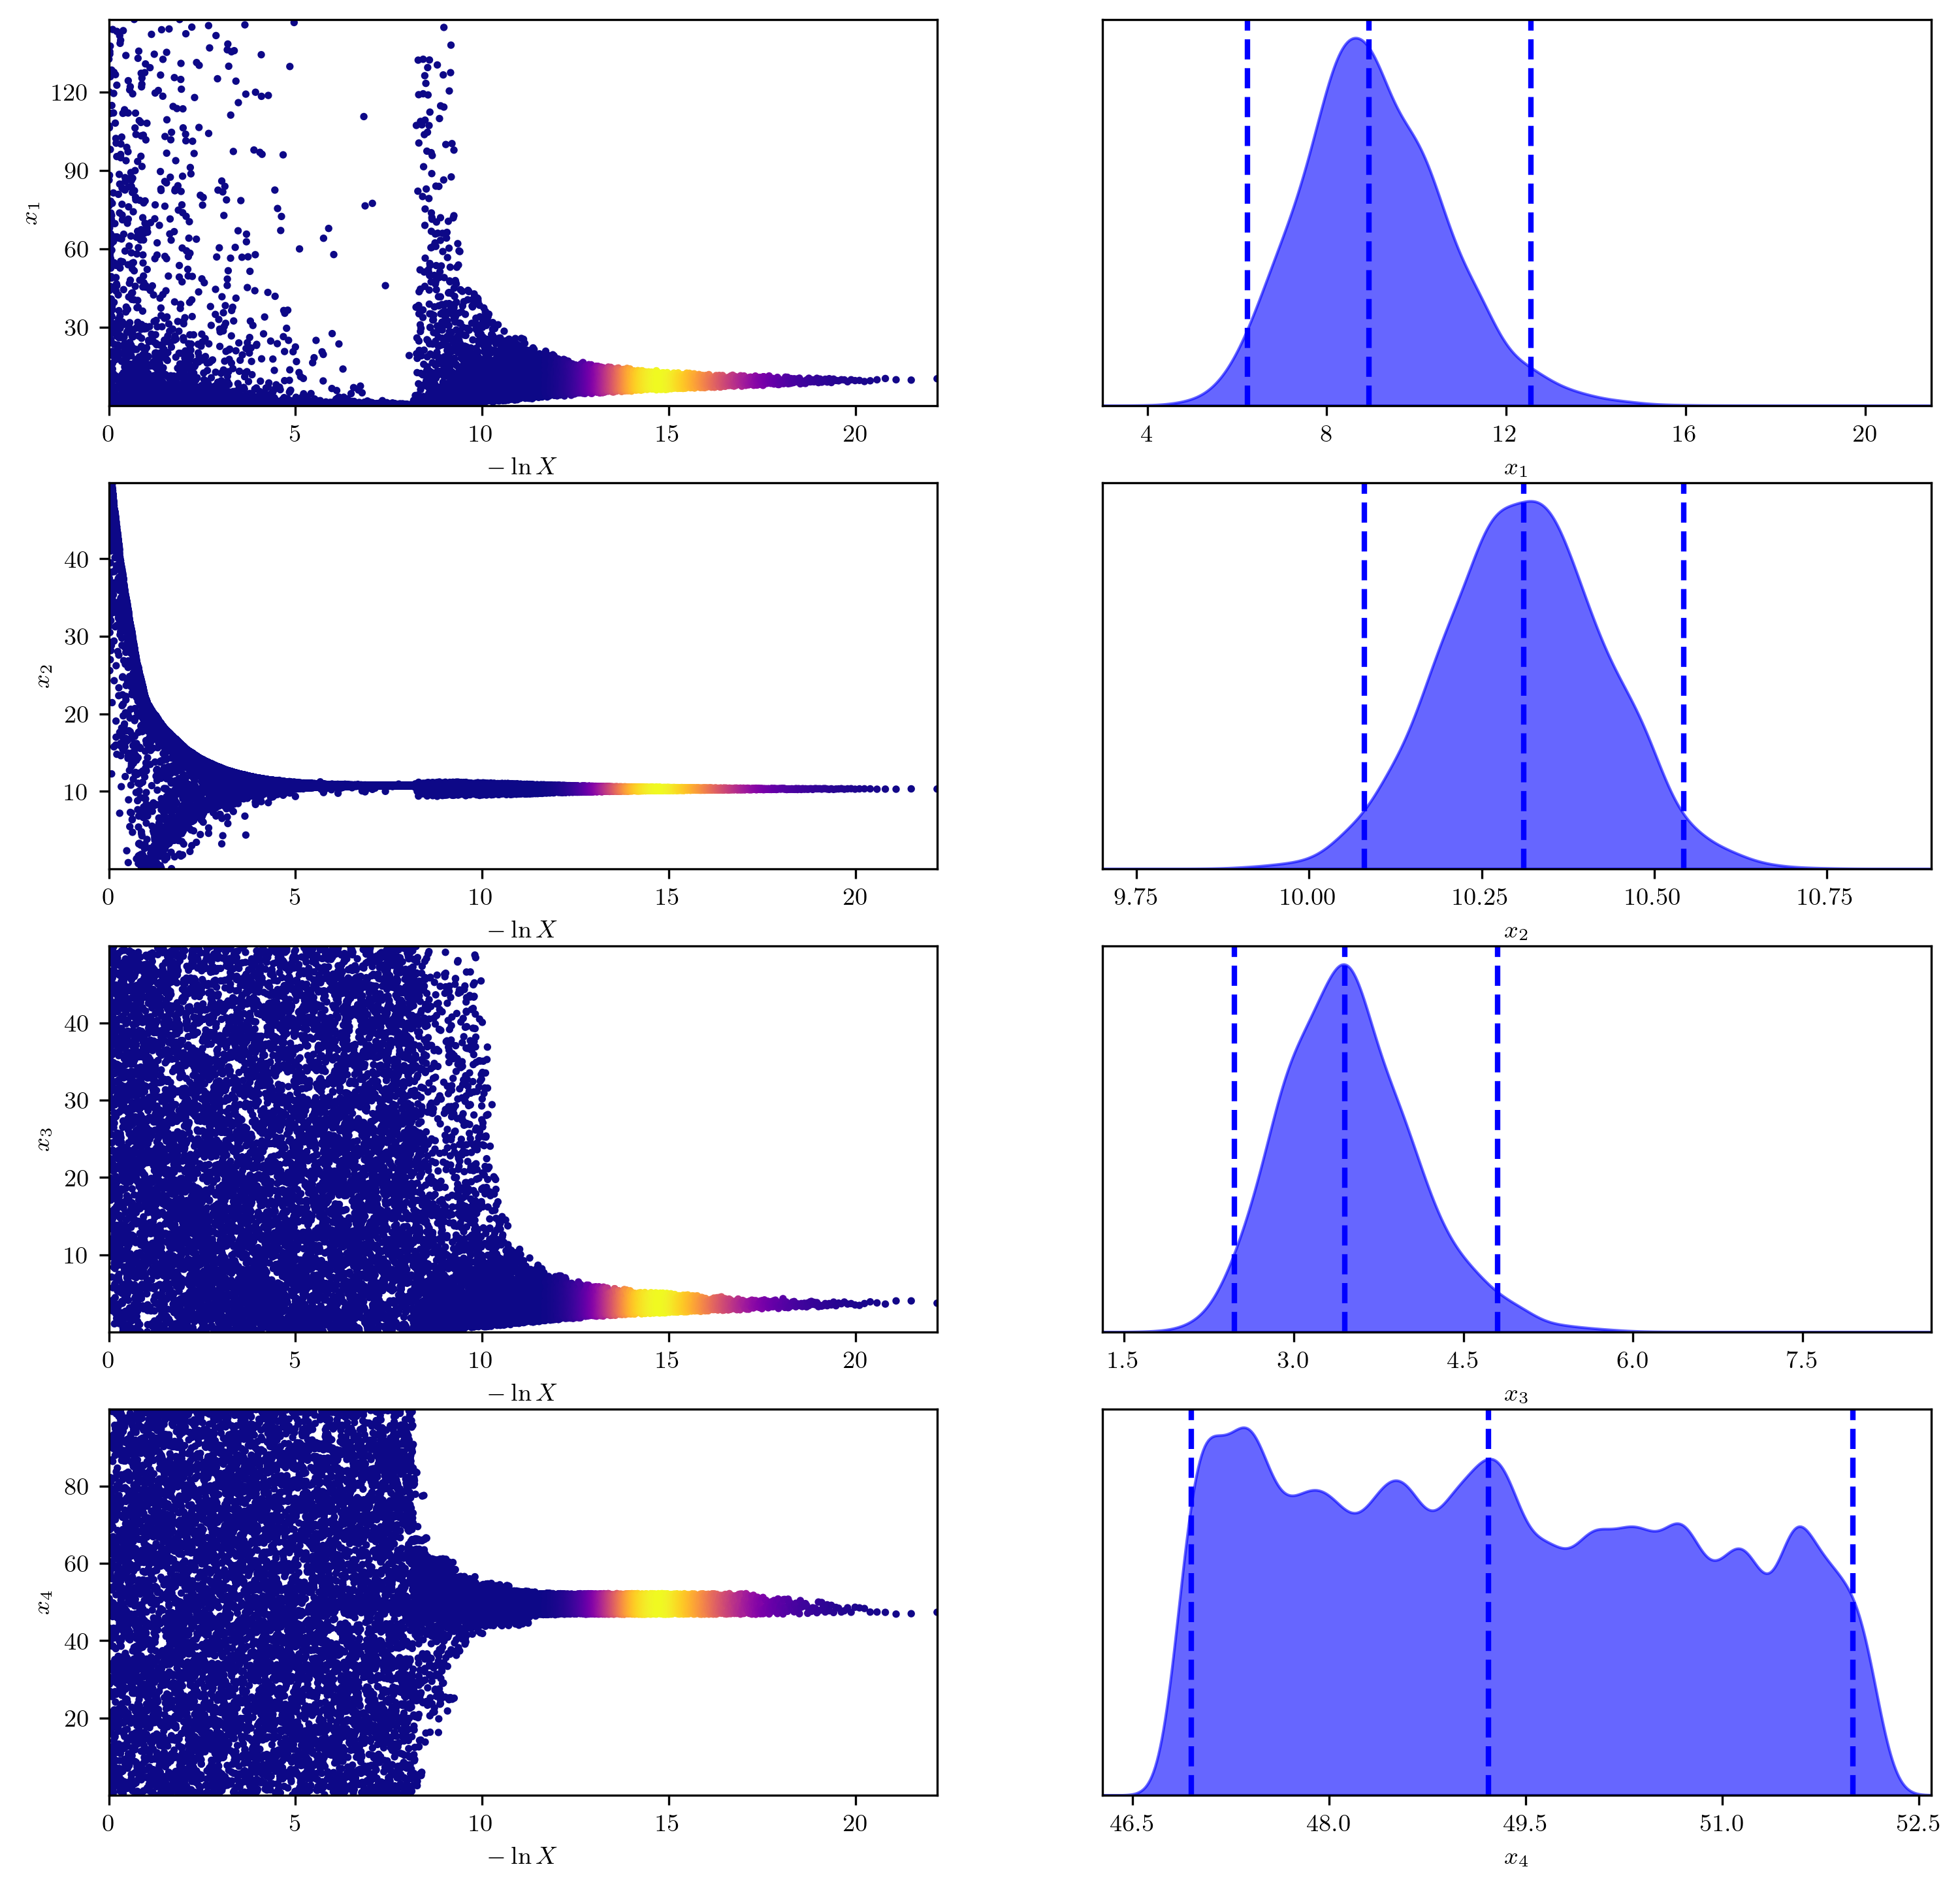

In [48]:
#-------------------------------------------------------------------------

rfig, raxes = dyplot.runplot(sresults2, color='black')

tfig, taxes = dyplot.traceplot(sresults2)

#-------------------------------------------------------------------------

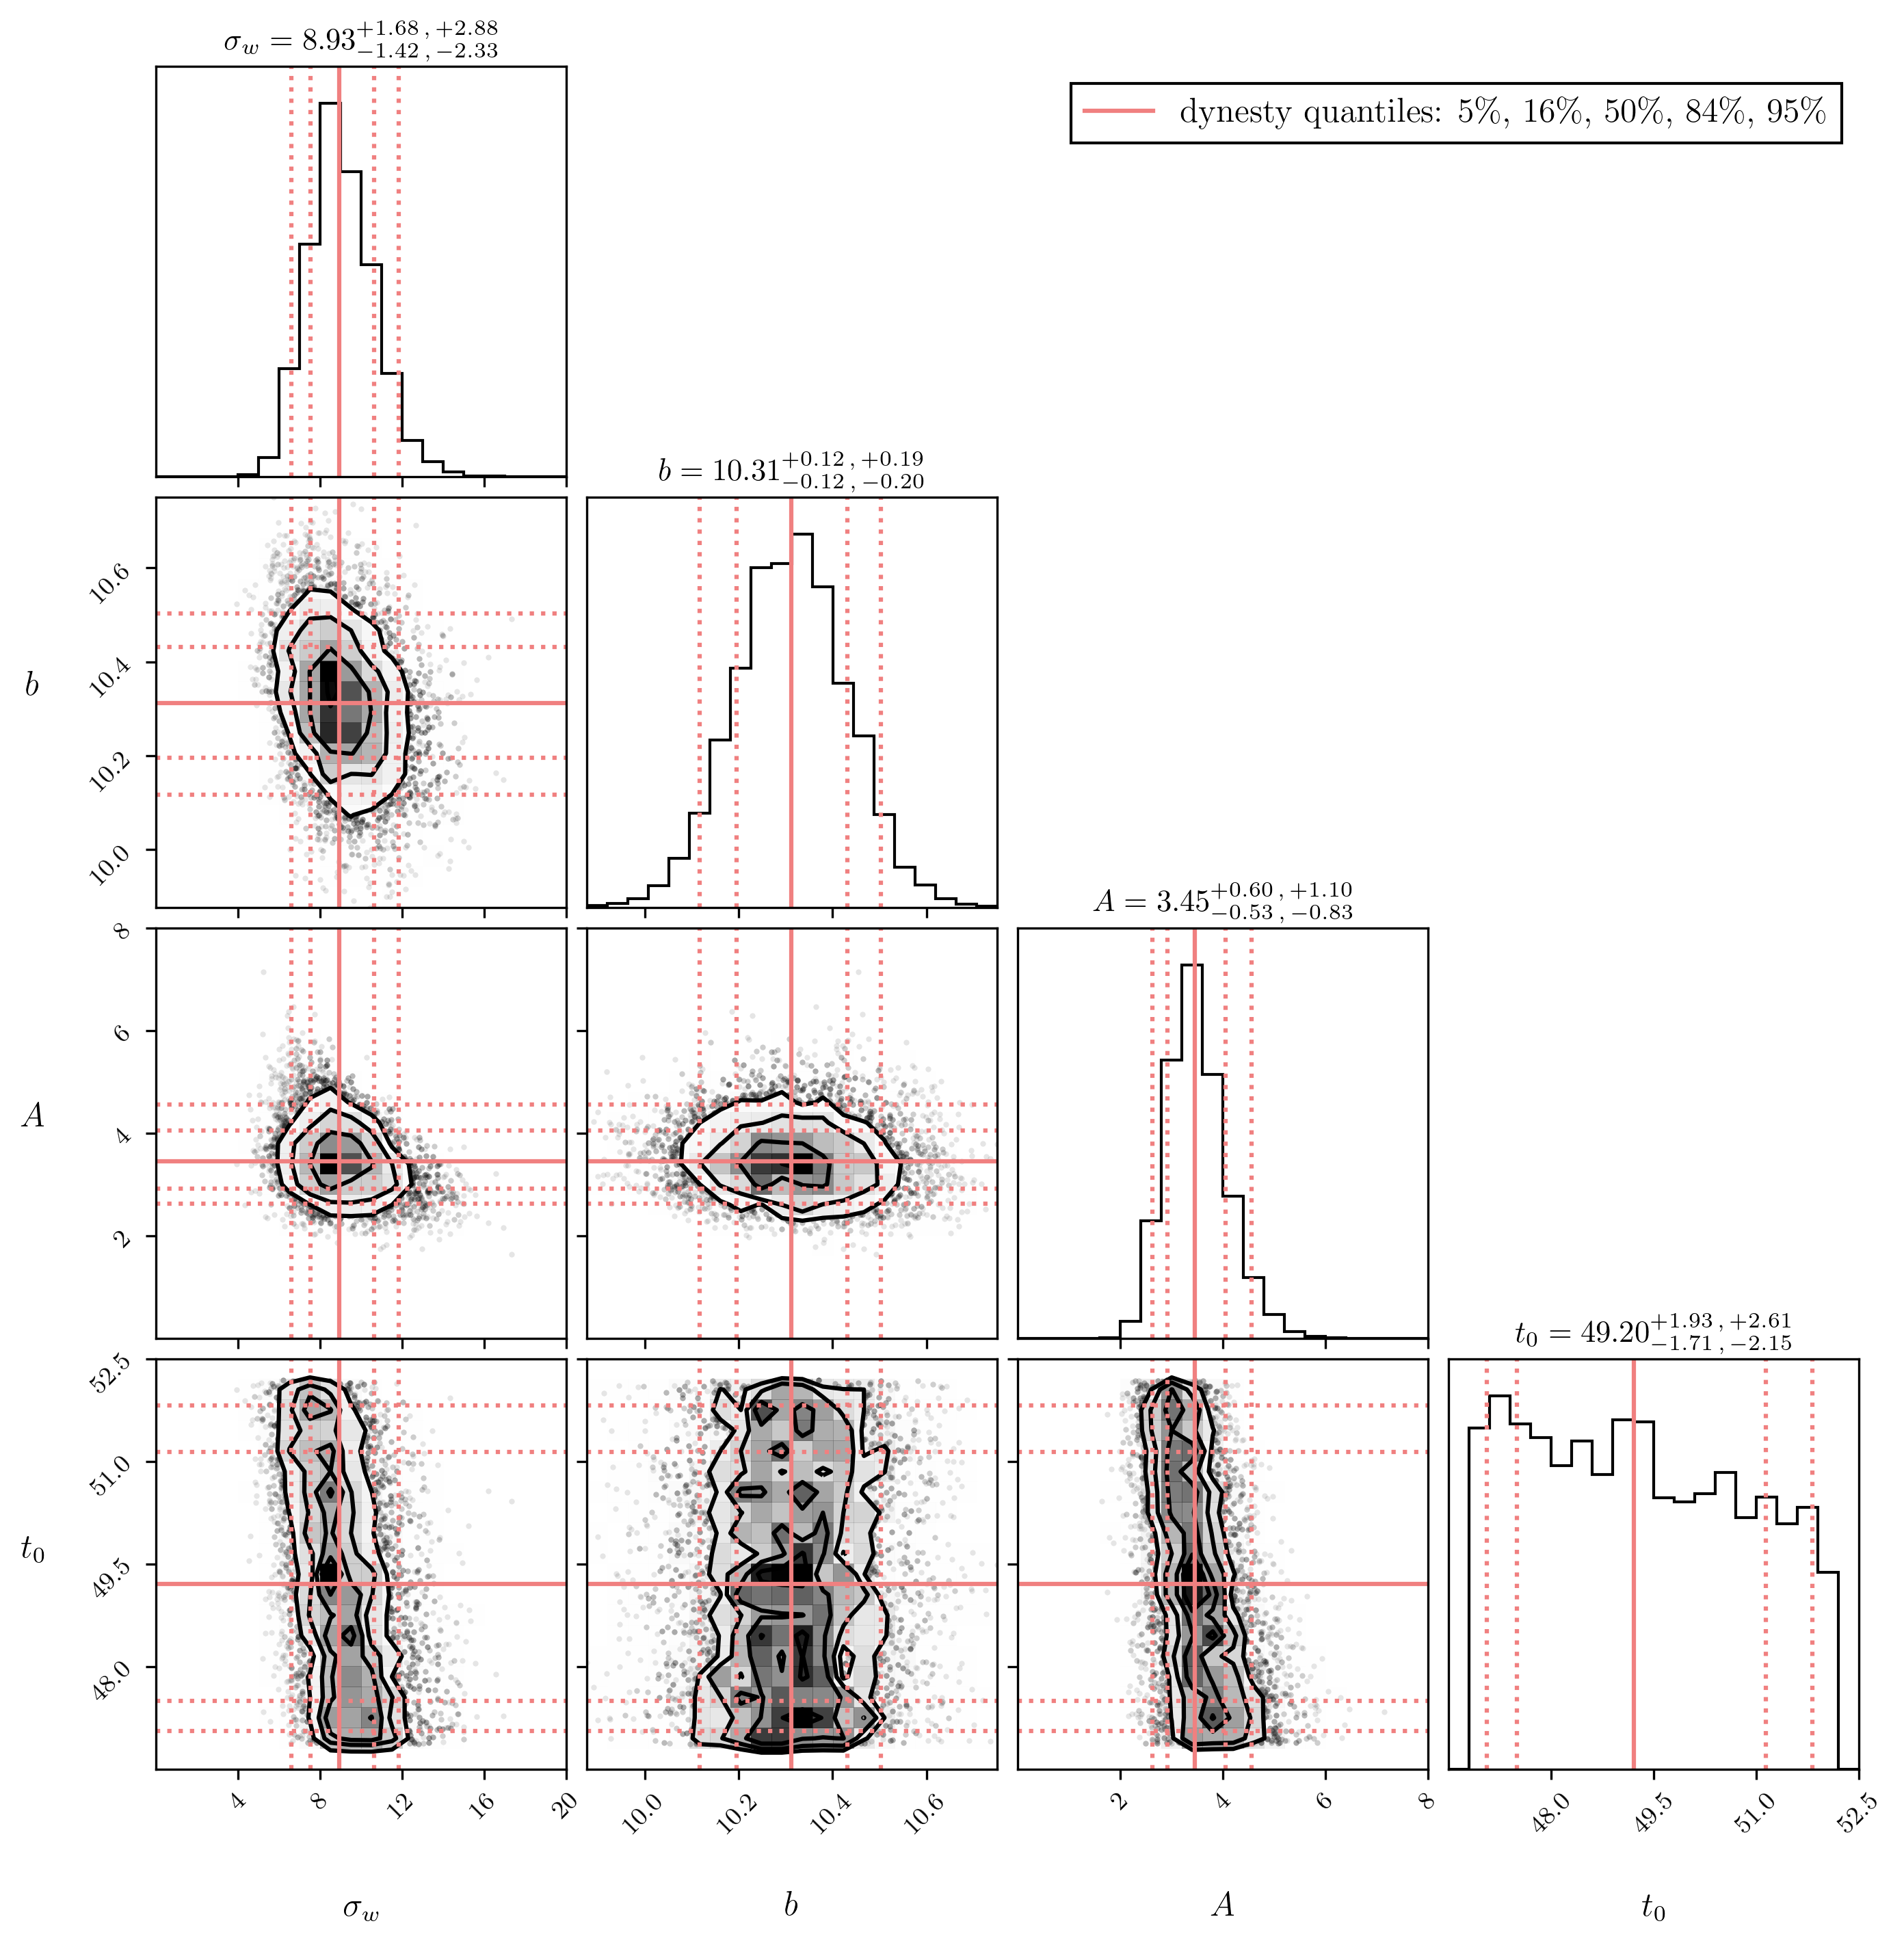

In [ ]:
#-------------------------------------------------------------------------
# 

samples2 = sresults2.samples  
normalized_weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])
samples_equal2 = dyfunc.resample_equal(samples2, normalized_weights2)


#-------------------------------------------------------------------------
# create the corner plot setup with the corner python package
# dynesty built-in corner plots: 
# cfig, caxes = dyplot.cornerplot(sresults1)

params_latex = [r'$\sigma_w$','$b$', '$A$', '$t_0$']
fontsize = 12
fig = corner.corner(
    samples_equal2,
    labels=params_latex,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize, 'rotation':'horizontal'},
    range        = [(0.,20), 1., (0.,8), (46.5,52.5)]
)
ax = np.array(fig.axes).reshape((n_dim, n_dim))

#-------------------------------------------------------------------------
# compute ranked statistics for the marginals (1D histograms): quantiles

quantiles2 = np.zeros((5,n_dim))
for i in range(n_dim):
    quantiles2[:,i] = corner.quantile(samples_equal2[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

#-------------------------------------------------------------------------
# print these quantiles results onto the histograms and as sub-titles 

ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='dynesty quantiles: 5\%, 16\%, 50\%, 84\%, 95\%')

corner.overplot_lines(fig, quantiles2[2,:], color="lightcoral")
corner.overplot_lines(fig, quantiles2[0,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles2[1,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles2[3,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles2[4,:], color="lightcoral", ls=':')

par_name = [r'\sigma_w', 'b', 'A', 't_0']
for i in range(n_dim):
    titles = '$' + par_name[i] + '=' + \
             '{:.2f}'.format(quantiles2[2,i]) + r'^{+' + \
             '{:.2f}'.format(quantiles2[3,i] - quantiles2[2,i]) + r'\, , \,+' + \
             '{:.2f}'.format(quantiles2[4,i] - quantiles2[2,i]) + r'}_{-'      + \
             '{:.2f}'.format(quantiles2[2,i] - quantiles2[1,i]) + r'\, , \,-'  + \
             '{:.2f}'.format(quantiles2[2,i] - quantiles2[0,i]) + r'}$'
    ax[i,i].set_title( titles )

#-------------------------------------------------------------------------
# utility: make legend, save figure:

ax[0,n_dim-1].legend(title_fontsize=fontsize, fontsize=fontsize, frameon=True, framealpha=1, fancybox=False, edgecolor='black', )

if True:
    fig.savefig('./L12_images/L12_dynesty__Corner_Plot_2.pdf', bbox_inches='tight')


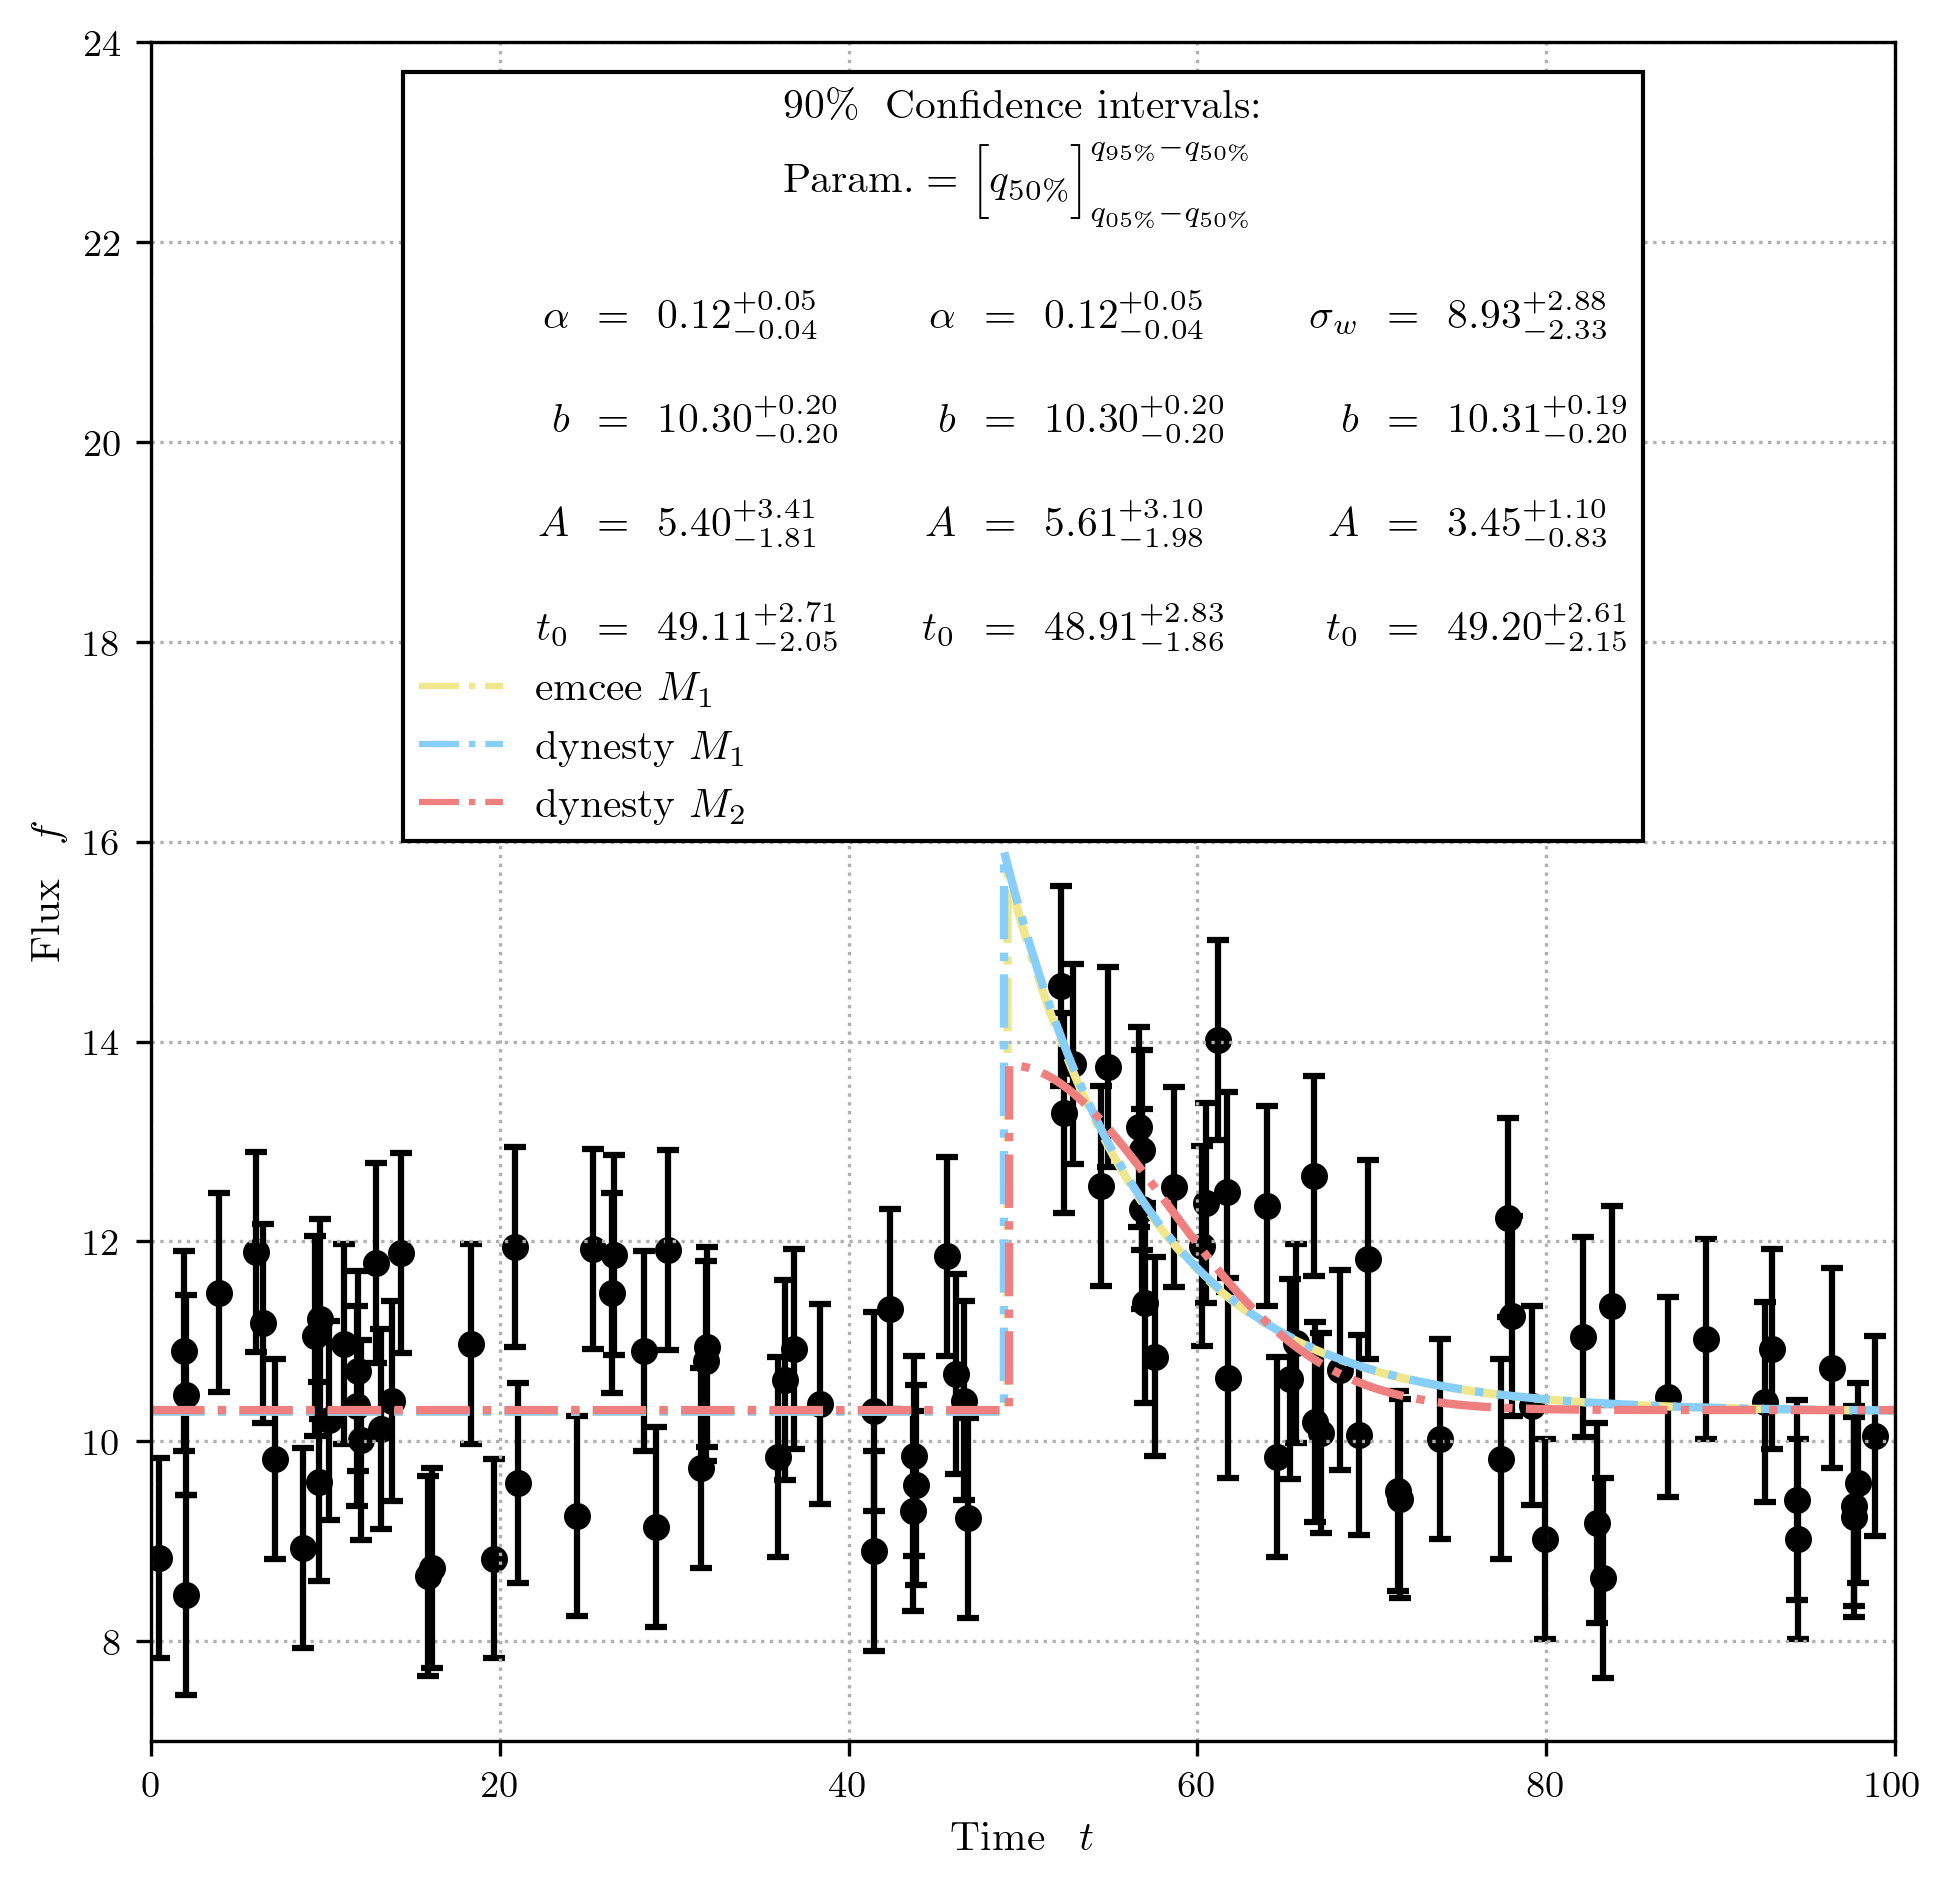

In [76]:
#-------------------------------------------------------------------------
# Plot the results of the parameter estimation over the observed data
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# initialize matplotlib figure and axes

fig , ax = plt.subplots(figsize=(7.5,7.5))
fontsize = 10
ax.set_xlim(0,100)
ax.set_ylim(7,24)
ax.grid(ls=':')
# ax.set_title(r'Event Model: \quad' + latexfunc + '\n', fontsize=15)
ax.set_xlabel(r'Time \, $t$', fontsize=fontsize)
ax.set_ylabel(r'Flux \, $f$', fontsize=fontsize) #, rotation='horizontal', labelpad=30)
    
#-------------------------------------------------------------------------
# plot the original data:

for i in range(len(T)):                                                       #for t, f, ef in zip(T, F, eF):
    ax.vlines(T[i], ymin=F[i]-eF[i], ymax=F[i]+eF[i], color='black' )          #ax.vlines( t, ymin=t-ef, ymax=t+ef)
ax.scatter(T, F + eF, color='black', s=30, marker='_')
ax.scatter(T, F - eF, color='black', s=30, marker='_')
ax.scatter(T, F, color='black', s=30, marker='o') # , label='')

#-------------------------------------------------------------------------
# plot the median and 90% credible region of the marginalized distribution: (done something similar above)

legend_title  = r'90\%' + '\; Confidence intervals:' + '\n' + 'Param.'
legend_title += r'$ \; = \Big[ q_{50\%} \Big]^{ q_{95\%} - q_{50\%}}_{ q_{05\%} - q_{50\%}}  $' + '\n'

label_results = '$' + r'\begin{array}{rcl}'
par_name = [r'\alpha', 'b', 'A', 't_0']
for i in range(n_dim):
    label_results += par_name[i] + r'\!&\! = \!&\!' + \
             '{:2.2f}'.format(quantiles0[2,i]) + r'^{+' + \
             '{:1.2f}'.format(quantiles0[4,i] - quantiles0[2,i]) + r'}_{-'      + \
             '{:1.2f}'.format(quantiles0[2,i] - quantiles0[0,i]) + r'}' + r'\\ \\'
label_results += r'\end{array} $' + r'$\quad$'
label_results += '$' + r'\begin{array}{rcl}'
for i in range(n_dim):
    label_results += par_name[i] + r'\!&\! = \!&\!' + \
             '{:2.2f}'.format(quantiles1[2,i]) + r'^{+' + \
             '{:1.2f}'.format(quantiles1[4,i] - quantiles1[2,i]) + r'}_{-'      + \
             '{:1.2f}'.format(quantiles1[2,i] - quantiles1[0,i]) + r'}' + r'\\ \\'
label_results += r'\end{array} $' + r'$\quad$'
label_results += '$' + r'\begin{array}{rcl}'
par_name = [r'\sigma_w', 'b', 'A', 't_0']
for i in range(n_dim):
    label_results += par_name[i] + r'\!&\! = \!&\!' + \
             '{:2.2f}'.format(quantiles2[2,i]) + r'^{+' + \
             '{:1.2f}'.format(quantiles2[4,i] - quantiles2[2,i]) + r'}_{-'      + \
             '{:1.2f}'.format(quantiles2[2,i] - quantiles2[0,i]) + r'}' + r'\\ \\'
label_results += r'\end{array} $' 

ax.scatter( [], [], marker='', label=label_results)

#-------------------------------------------------------------------------
# plot also the best fit curve computed with the medians:


y_lin = flux_model(quantiles0[2,:], t_lin)
ax.plot(t_lin, y_lin, color='khaki', alpha=1., ls='-.', lw=2)
ax.plot([], [], ls='-.', color='khaki', label='emcee $M_1$')

y_lin = flux_model(quantiles1[2,:], t_lin)
ax.plot(t_lin, y_lin, color='lightskyblue', alpha=1., ls='-.', lw=2)
ax.plot([], [], ls='-.', color='lightskyblue', label='dynesty $M_1$')

y_lin = flux_model2(quantiles2[2,:], t_lin)
ax.plot(t_lin, y_lin, color='lightcoral', alpha=1., ls='-.', lw=2)
ax.plot([], [], ls='-.', color='lightcoral', label='dynesty $M_2$')


#-------------------------------------------------------------------------
# Utilities: plot the 'title' with the functional form of the transient event model, save figure

ax.legend(title=legend_title, 
          title_fontsize=fontsize, 
          fontsize=fontsize, 
          frameon=True, 
          framealpha=1, 
          fancybox=False, 
          edgecolor='black', 
          loc='upper center',
          bbox_to_anchor=(0.500,0.995)
         )

props = dict(boxstyle='square', facecolor='white', alpha=1.)

# string = ax.text(0.025, 0.995, 
#                  '\n' + r'Event Model:' + '\n' + latexfunc, 
#                  transform=ax.transAxes, 
#                  fontsize=fontsize,
#                  verticalalignment='top', 
#                  horizontalalignment='left', 
#                  bbox=props
#                 )

if True:
    fig.savefig('./L12_images/L12_dynesty__Observations_and_Estimated_Parameters.pdf', bbox_inches='tight')


In order to compare the 2 models for the flux of the transient events, we use the evidence, which is computed by dynesty as:

$$\mathcal{Z} = \int p(d|\theta)\,p(\theta) \, \textup{d}^n\theta = \int_0^1 \mathcal{L}(X) \, \textup{d}X.$$

More specifically, we compute the ratio of the evidences (the Bayes factor) and compare it against the tabulated values:

$$
\mathcal{B} = \dfrac{ \mathcal{Z}_1 }{ \mathcal{Z}_2 } = \exp\big( \log \mathcal{Z}_1 - \log \mathcal{Z}_2 \big)
$$

Our results suggest that any discrepance between the two models is "barely worth mentioning"; this is also intuitively understandable from the plot above. 

In [79]:
logZ1 = sresults1.logz[-1]
logZ2 = sresults2.logz[-1]
logB = logZ1 - logZ2
B = np.exp( logB )

print(B, logB)

1.1829950729346737 0.1680494200971907
